# Reto 2 · Análisis exploratorio de datos

**Fenotipado digital de secuelas post-infecciosas.** Notebook 01: exploración de la cohorte unificada antes de definir fenotipos.

**Pregunta de este notebook:** ¿qué datos tenemos realmente, de quién, cuándo y con qué calidad? De la respuesta dependen las decisiones del fenotipado: qué variables definen los fenotipos, en qué ventana temporal, qué cohorte descubre y cuál replica.

| Sección | Contenido |
|---|---|
| 0 | Entorno y configuración |
| 1 | Universo de pacientes y trazabilidad entre registros |
| 2 | Calidad de datos: cumplimentación, códigos y eje temporal |
| 3 | Mapa de ausencias: estructural frente a no cumplimentado |
| 4 | Demografía y comorbilidad basal |
| 5 | Gravedad del episodio agudo |
| 6 | Momento del seguimiento (`visita_dias`) |
| 7 | Función pulmonar, esfuerzo y disnea en la primera visita |
| 8 | Trayectorias de DLCO y abandono informativo |
| 9 | Dominios de la capa B: ansiedad, depresión y disnea en el tiempo |
| 10 | Imagen torácica (TAC) |
| 11 | Resumen de hallazgos e implicaciones para el fenotipado |

> **Privacidad.** Los datos están seudonimizados, no anonimizados. Este notebook solo muestra **agregados**: no se imprime ninguna fila de paciente, los diagramas de caja se dibujan sin puntos atípicos individuales y los recuentos < 10 se suprimen en las tablas (`src/privacidad.py`).

## 0 · Entorno y configuración

In [1]:
import sys
import importlib.util
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, privacidad

warnings.filterwarnings("ignore", category=FutureWarning)
cfg = carga.cargar_config()
np.random.seed(cfg["semilla"])

N_MIN = cfg["privacidad"]["n_minimo_celda"]
REG = list(cfg["registros"])
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida",
       "TENACITY": "TENACITY", "VIRGEN_DEL_ROCIO": "Virgen del Rocío"}
PALETA = [COLOR[r] for r in REG]
UMB = cfg["umbrales_clinicos"]

FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


def guardar(fig, nombre: str) -> None:
    """Guarda la figura en outputs/figuras."""
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", dpi=150)


def ic_wilson(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """Intervalo de confianza de Wilson para una proporción (en %)."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    centro = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return (100 * (centro - margen), 100 * (centro + margen))


def nota(ax, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    # Texto a nivel de figura: tight_layout no lo tiene en cuenta y no comprime los paneles
    fig = ax.figure
    n_previas = getattr(fig, "_n_notas", 0)        # varias notas en la misma figura se apilan
    fig.text(0.01, -0.01 - 0.05 * n_previas, texto, fontsize=8.5, color="0.35", va="top", ha="left")
    fig._n_notas = n_previas + texto.count("\n") + 1

In [2]:
# Librerías que necesitará el pipeline de fenotipado
necesarias = {"pandas": "tablas", "numpy": "cálculo", "scipy": "estadística, algoritmo húngaro",
              "sklearn": "métricas, clasificadores", "statsmodels": "modelos mixtos",
              "gower": "distancia de Gower", "sklearn_extra": "KMedoids (PAM)",
              "matplotlib": "figuras", "seaborn": "figuras", "plotly": "figuras interactivas", "yaml": "config"}
pd.DataFrame([{"librería": lib, "uso": uso, "disponible": importlib.util.find_spec(lib) is not None}
              for lib, uso in necesarias.items()]).set_index("librería")

,uso,disponible
librería,,
pandas,tablas,True
numpy,cálculo,True
scipy,"estadística, algoritmo húngaro",True
sklearn,"métricas, clasificadores",True
statsmodels,modelos mixtos,True
gower,distancia de Gower,False
sklearn_extra,KMedoids (PAM),False
matplotlib,figuras,True
seaborn,figuras,True


`gower` y `scikit-learn-extra` no están instaladas. Alternativas para los siguientes notebooks:
- **Gower**: implementarla en `numpy` (rango por variable numérica, coincidencia para binarias y categóricas, ponderada por los pares disponibles). Son unas 30 líneas y así controlamos cómo se tratan las ausencias.
- **PAM**: `pip install scikit-learn-extra` (no tiene ruedas para Python 3.13 en todas las plataformas). Si falla, se puede usar el paquete `kmedoids` (FasterPAM) o una implementación propia de PAM sobre la matriz precomputada.

## 1 · Universo de pacientes y trazabilidad

Una fila por paciente. 459 pacientes están en dos registros y ocupan **una sola fila, la de CIBERESUCICOVID**. Para describir un registro completo se usan las banderas `en_<registro>`. La columna `cohorte` indica a qué registro pertenece la fila, no el paciente.

In [3]:
nucleo = carga.cargar_nucleo(cfg)
dic = carga.cargar_diccionario(cfg)
por_registro = carga.pertenencia_larga(nucleo, cfg)   # una fila por (paciente, registro)

print(f"Tabla núcleo: {nucleo.shape[0]:,} pacientes × {nucleo.shape[1]} columnas")
print(f"Pacientes únicos: {nucleo['subject_id'].nunique():,}")
print(f"Filas (paciente, registro): {len(por_registro):,}  ->  {len(por_registro) - len(nucleo)} pacientes en dos registros")

Tabla núcleo: 9,809 pacientes × 39 columnas
Pacientes únicos: 9,809
Filas (paciente, registro): 10,268  ->  459 pacientes en dos registros


In [4]:
resumen = []
for r, bandera in cfg["registros"].items():
    sub = nucleo[nucleo[bandera] == 1]
    resumen.append({
        "registro": ETQ[r],
        "pacientes (en_)": len(sub),
        "filas propias (cohorte)": int((nucleo["cohorte"] == r).sum()),
        "en fila de CIBERESUCICOVID": int(((sub["cohorte"] == "CIBERESUCICOVID") & (r != "CIBERESUCICOVID")).sum()),
        "centros": sub["centro_id"].nunique(),
        "% con centro conocido": round(100 * sub["centro_id"].notna().mean(), 1),
    })
tabla_universo = pd.DataFrame(resumen).set_index("registro")
tabla_universo

,pacientes (en_),filas propias (cohorte),en fila de CIBERESUCICOVID,centros,% con centro conocido
registro,,,,,
CIBERESUCICOVID,9274,9274,0,76,78.0
POSTCOVID-Lleida,624,187,437,2,90.2
TENACITY,287,287,0,3,66.2
Virgen del Rocío,83,61,22,1,53.0


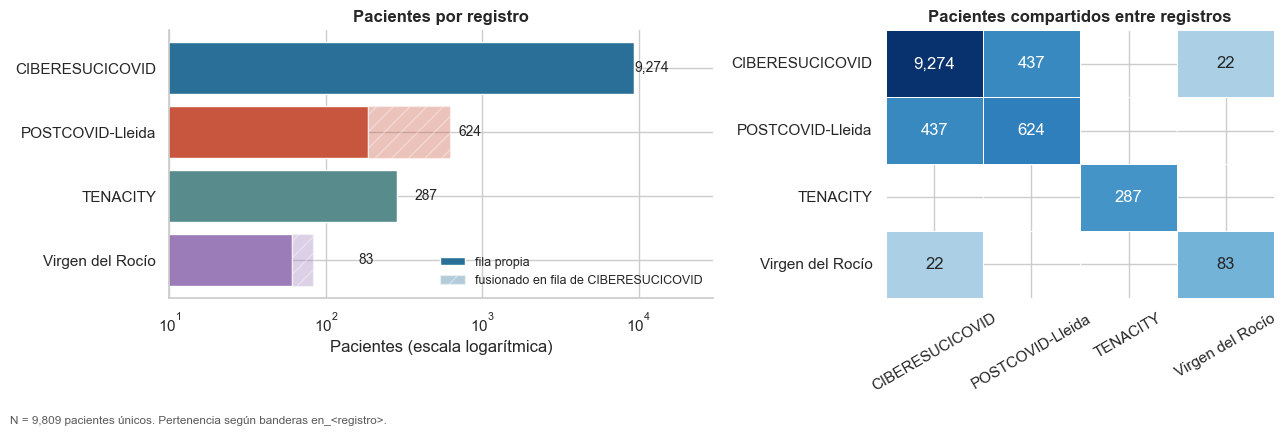

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})

ax = axes[0]
propias = tabla_universo["filas propias (cohorte)"]
fusion = tabla_universo["en fila de CIBERESUCICOVID"]
y = np.arange(len(REG))
ax.barh(y, propias, color=PALETA, label="fila propia")
ax.barh(y, fusion, left=propias, color=PALETA, alpha=0.35, hatch="//", label="fusionado en fila de CIBERESUCICOVID")
for i, (p, f) in enumerate(zip(propias, fusion)):
    ax.text(p + f + 80, i, f"{p + f:,}", va="center", fontsize=10)
ax.set_yticks(y, [ETQ[r] for r in REG]); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xlim(10, 30000)
ax.set_xlabel("Pacientes (escala logarítmica)")
ax.set_title("Pacientes por registro")
ax.legend(loc="lower right", fontsize=9, frameon=False)

ax = axes[1]
banderas = list(cfg["registros"].values())
solape = pd.DataFrame([[int(((nucleo[a] == 1) & (nucleo[b] == 1)).sum()) for b in banderas] for a in banderas],
                      index=[ETQ[r] for r in REG], columns=[ETQ[r] for r in REG])
sns.heatmap(solape, annot=True, fmt=",", cmap="Blues", norm=plt.matplotlib.colors.LogNorm(vmin=1, vmax=10000),
            cbar=False, ax=ax, linewidths=0.5, mask=solape == 0)
ax.set_title("Pacientes compartidos entre registros")
ax.tick_params(axis="x", rotation=30)
nota(axes[0], f"N = {len(nucleo):,} pacientes únicos. Pertenencia según banderas en_<registro>.")
plt.tight_layout(); guardar(fig, "01_universo_registros"); plt.show()

**Lectura.**
- CIBERESUCICOVID aporta el 95 % de los pacientes. Lleida, TENACITY y Virgen del Rocío juntas suman 994 pacientes distintos.
- **El 70 % de Lleida (437/624) vive en filas de CIBERESUCICOVID** (`fusionada_lleida == 1`). Si se descubre en CIBERESUCICOVID y se replica en Lleida sin quitar a esos pacientes de un lado, la "replicación" usaría en parte a los mismos pacientes.
- Lleida, TENACITY y Virgen del Rocío proceden de 1–3 centros (en Lleida aparecen 2 porque las filas fusionadas heredan el centro de CIBERESUCICOVID). CIBERESUCICOVID tiene 76 centros, lo que permite la validación *leave-one-center-out* dentro de esta cohorte.
- TENACITY no comparte pacientes con ningún otro registro: es la cohorte de replicación más limpia.

## 2 · Calidad de datos

### 2.1 Cumplimentación del conjunto mínimo de datos en CIBERESUCICOVID (`IH_PorcCMD`)

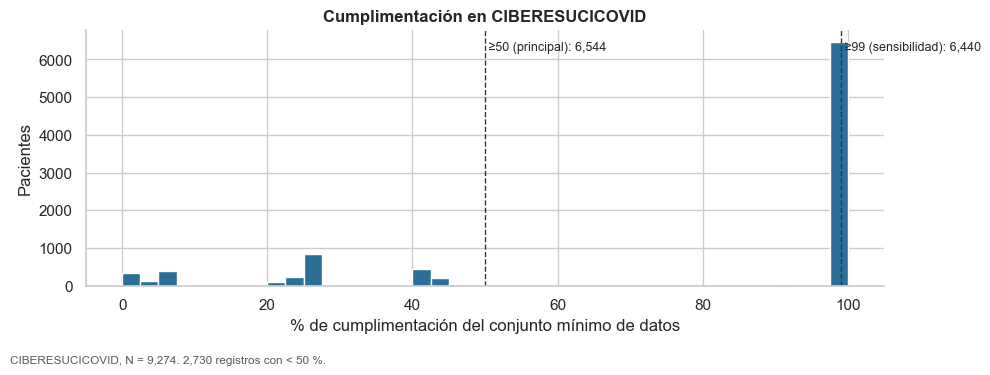

In [6]:
cmd = carga.cargar_columnas_completa(cfg, ["IH_PorcCMD"])
nucleo = nucleo.merge(cmd, on="subject_id", how="left")
cib = nucleo[nucleo["en_CIBERESUCICOVID"] == 1]
u_p, u_s = cfg["calidad"]["ih_porccmd_principal"], cfg["calidad"]["ih_porccmd_sensibilidad"]

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(cib["IH_PorcCMD"].dropna(), bins=np.arange(0, 102.5, 2.5), color=COLOR["CIBERESUCICOVID"], edgecolor="white")
for u, txt in [(u_p, "principal"), (u_s, "sensibilidad")]:
    ax.axvline(u, color="0.2", ls="--", lw=1)
    ax.text(u, ax.get_ylim()[1] * 0.92, f" ≥{u} ({txt}): {int((cib['IH_PorcCMD'] >= u).sum()):,}", fontsize=9)
ax.set_xlabel("% de cumplimentación del conjunto mínimo de datos"); ax.set_ylabel("Pacientes")
ax.set_title("Cumplimentación en CIBERESUCICOVID")
nota(ax, f"CIBERESUCICOVID, N = {cib['IH_PorcCMD'].notna().sum():,}. {int((cib['IH_PorcCMD'] < u_p).sum()):,} registros con < {u_p} %.")
plt.tight_layout(); guardar(fig, "02_cumplimentacion_cmd"); plt.show()

In [7]:
# ¿Los registros poco cumplimentados son pacientes distintos o solo formularios incompletos?
cib = cib.assign(cmd_ok=np.where(cib["IH_PorcCMD"] >= u_p, f"≥{u_p} %", f"<{u_p} %"))
comparar = {
    "Edad conocida": cib["edad_tramo5"].notna(),
    "Sexo conocido": cib["sexo"].notna(),
    "Estancia conocida": cib["estancia_hosp_dias"].notna(),
    "Exitus conocido": cib["nu_exitus_hosp"].notna(),
    "Exitus hospitalario": cib["nu_exitus_hosp"] == 1,
    "Con DLCO en seguimiento": cib["nu_dlco_pct_seg"].notna(),
    "Con visita de seguimiento": cib["visita_dias"].notna(),
}
tabla_cmd = pd.DataFrame({k: v.groupby(cib["cmd_ok"]).mean() * 100 for k, v in comparar.items()}).T.round(1)
tabla_cmd.columns = [f"{c} (N={int((cib['cmd_ok'] == c).sum()):,})" for c in tabla_cmd.columns]
tabla_cmd

,"<50 % (N=2,730)","≥50 % (N=6,544)"
Edad conocida,82.9,99.9
Sexo conocido,83.0,99.8
Estancia conocida,55.8,99.5
Exitus conocido,20.9,99.8
Exitus hospitalario,8.2,30.7
Con DLCO en seguimiento,0.5,19.5
Con visita de seguimiento,0.4,35.0


Los 2.730 registros con menos del 50 % de cumplimentación son, en la práctica, **pacientes sin seguimiento**: menos del 1 % tiene visita o DLCO, y al 79 % le falta el estado vital al alta. Consecuencias:
- Para el **fenotipado** (que exige seguimiento), el filtro `IH_PorcCMD ≥ 50` apenas cambia la población.
- Para **describir la fase aguda** de CIBERESUCICOVID sí importa: con todos los registros, la mortalidad hospitalaria parecería menor (8 % frente a 31 %) solo porque falta el dato.

Se declara ≥ 50 como análisis principal y ≥ 99 como sensibilidad.

### 2.2 Códigos de "se desconoce" (9) y otros valores especiales

In [8]:
crudo = pd.read_csv(carga.ruta_datos(cfg, "nucleo"), usecols=carga.VARIABLES_CODIGO_9 + ["sexo"])
codigos = pd.DataFrame({
    "valores = 9 (→ NaN)": (crudo[carga.VARIABLES_CODIGO_9] == 9).sum(),
    "NaN originales": crudo[carga.VARIABLES_CODIGO_9].isna().sum(),
})
codigos = codigos[codigos["valores = 9 (→ NaN)"] > 0]
print("sexo = 2 (no especificado):", int((crudo["sexo"] == 2).sum()))
privacidad.suprimir_celdas(codigos, N_MIN, ["valores = 9 (→ NaN)"])

sexo = 2 (no especificado): 0


,valores = 9 (→ NaN),NaN originales
nu_tabaquismo,552,2592
nu_exitus_hosp,<10,2704


El código 9 solo aparece de forma relevante en **tabaquismo** (552). En `exitus` es residual. Si no se convierte a ausente, el tabaquismo "9" entraría en la distancia como si fuera una categoría clínica. `cargar_nucleo` ya hace la conversión.

### 2.3 Eje temporal: `visita_dias` (días del alta a la primera visita)

In [9]:
vd = por_registro[por_registro["visita_dias"].notna()]
neg = vd[vd["visita_dias"] < 0].groupby("registro", observed=True).size()
fechas_ok = nucleo[["nu_fecha_alta", "nu_fecha_visita1", "visita_dias"]].dropna()
coherencia = ((fechas_ok["nu_fecha_visita1"] - fechas_ok["nu_fecha_alta"]).dt.days == fechas_ok["visita_dias"]).mean()

tabla_vd = pd.DataFrame({
    "N con visita_dias": vd.groupby("registro", observed=True).size(),
    "negativos": neg,
    "mediana (días)": vd.groupby("registro", observed=True)["visita_dias"].median(),
    "P10": vd.groupby("registro", observed=True)["visita_dias"].quantile(0.10),
    "P90": vd.groupby("registro", observed=True)["visita_dias"].quantile(0.90),
}).fillna(0).astype(int).rename(index=ETQ)
print(f"visita_dias = fecha_visita1 - fecha_alta en el {100 * coherencia:.1f} % de los casos con ambas fechas")
privacidad.suprimir_celdas(tabla_vd, N_MIN, ["negativos"])

visita_dias = fecha_visita1 - fecha_alta en el 100.0 % de los casos con ambas fechas


,N con visita_dias,negativos,mediana (días),P10,P90
registro,,,,,
CIBERESUCICOVID,2301,47,86,41,133
POSTCOVID-Lleida,610,<10,120,85,212
TENACITY,211,<10,106,85,148
Virgen del Rocío,81,<10,44,16,119


Hay visitas **anteriores al alta** (`visita_dias < 0`), casi todas en CIBERESUCICOVID. Son errores de fecha o reingresos. Decisión propuesta: excluirlas de cualquier análisis temporal y dejarlo anotado en `docs/registro_decisiones.md`. La columna coincide con la resta de fechas, así que el problema está en la fecha de origen y no en el cálculo.

## 3 · Mapa de ausencias

En la tabla completa, el 90,5 % de las celdas está vacío porque cada registro usó su propio cuaderno. Hay que separar dos tipos de hueco:
- **Ausencia estructural** (gris, "NR"): el registro no recoge esa variable. No se imputa nunca.
- **Ausencia por no cumplimentación** (color): el registro la recoge pero falta para ese paciente.

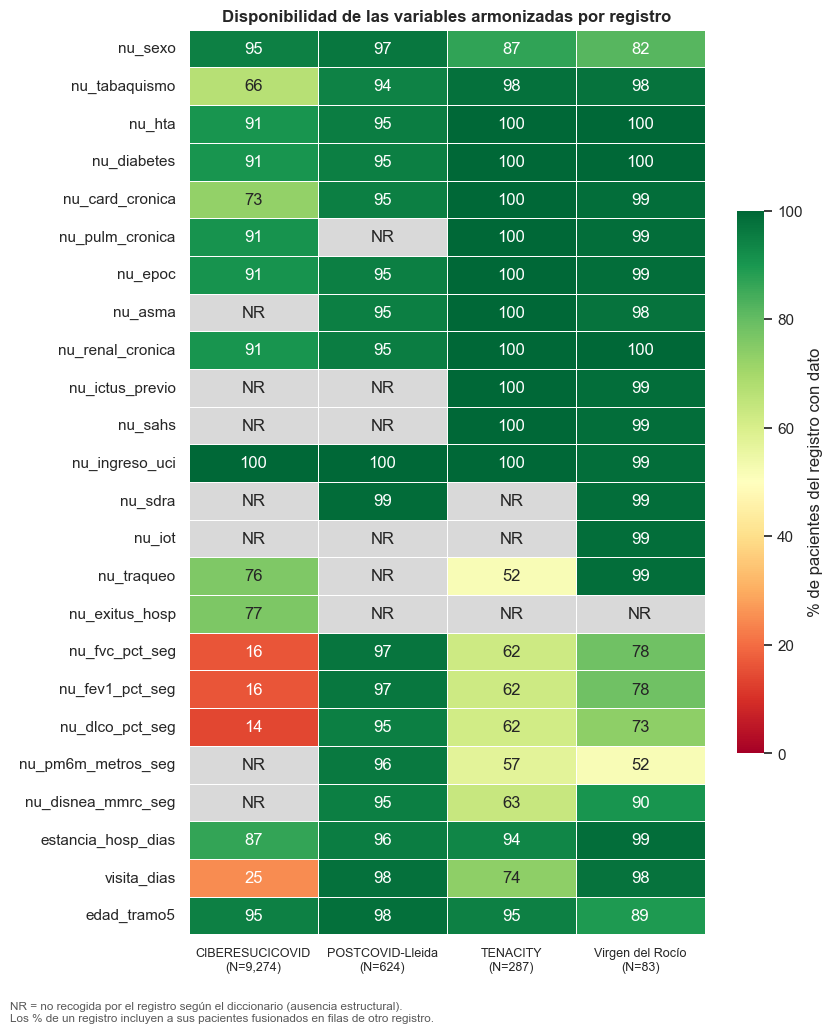

In [10]:
dic_nu = dic["nucleo"].set_index("Variable")
vars_nu = [c for c in nucleo.columns if c.startswith("nu_") and not c.startswith("nu_fecha")] + ["estancia_hosp_dias", "visita_dias", "edad_tramo5"]

disp = pd.DataFrame({r: por_registro[por_registro["registro"] == r][vars_nu].notna().mean() * 100 for r in REG})
# El diccionario indica en «La recogen» los registros separados por " · "
recoge = pd.DataFrame({r: [r in [x.strip() for x in str(dic_nu.loc[v, "La recogen"]).split("·")] if v in dic_nu.index else True
                           for v in vars_nu] for r in REG}, index=vars_nu)

anot = disp.round(0).astype(int).astype(str)
anot[~recoge] = "NR"
fig, ax = plt.subplots(figsize=(8.5, 10))
sns.heatmap(disp.where(recoge), annot=anot, fmt="", cmap="RdYlGn", vmin=0, vmax=100, ax=ax,
            linewidths=0.5, cbar_kws={"label": "% de pacientes del registro con dato", "shrink": 0.6})
sns.heatmap(disp.where(~recoge).notna().astype(float).where(~recoge), cmap=["#d9d9d9"], cbar=False, ax=ax,
            annot=anot.where(~recoge, ""), fmt="", linewidths=0.5)
ax.set_xticklabels([f"{ETQ[r]}\n(N={int(nucleo[cfg['registros'][r]].sum()):,})" for r in REG], rotation=0, fontsize=9)
ax.set_title("Disponibilidad de las variables armonizadas por registro")
nota(ax, "NR = no recogida por el registro según el diccionario (ausencia estructural).\n"
         "Los % de un registro incluyen a sus pacientes fusionados en filas de otro registro.")
plt.tight_layout(); guardar(fig, "03_mapa_ausencias_nucleo"); plt.show()

**Lectura.**
- Las variables de seguimiento (`nu_*_seg`) son las que definirán los fenotipos. **En CIBERESUCICOVID solo el ~14–16 % tiene espirometría o DLCO**, frente a más del 95 % en Lleida. La ventaja de N de CIBERESUCICOVID baja de 9.274 a unos 1.300 pacientes en la capa A.
- **PM6M y mMRC no existen en CIBERESUCICOVID** (ausencia estructural). La capa A no puede usarlas si se descubre en esta cohorte.
- Algunas casillas "no recogidas" tienen valores, por ejemplo `nu_exitus_hosp` en Lleida. Corresponden a pacientes fusionados que heredan datos de CIBERESUCICOVID: la regla "esta variable solo existe en tal cohorte" falla en las filas fusionadas o enriquecidas.

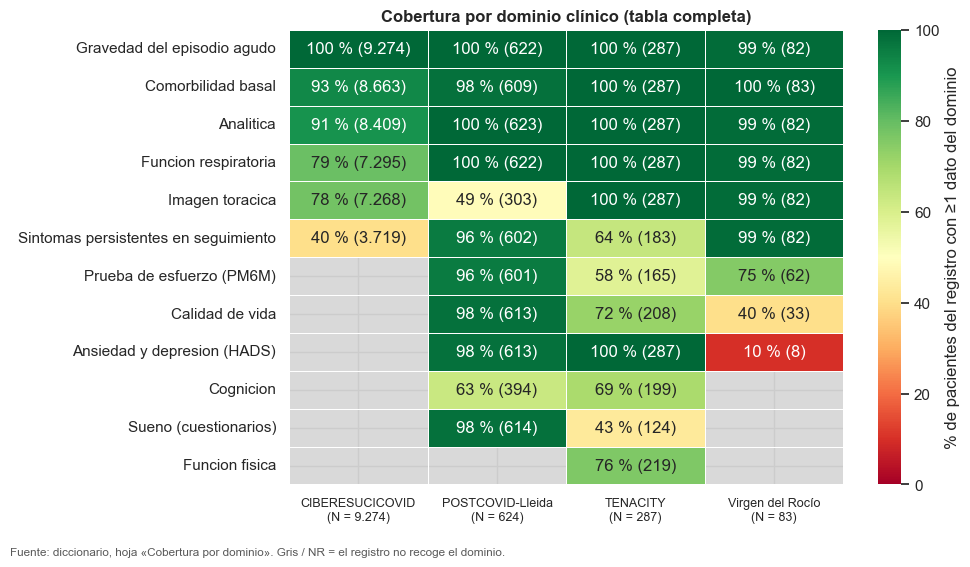

In [11]:
cob = dic["cobertura"].set_index("Dominio clínico")
num = cob.apply(lambda s: s.astype(str).str.extract(r"(\d+)\s*%")[0].astype(float))
etq = cob.astype(str).replace({"no se recoge": "NR"})
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(num, annot=etq, fmt="", cmap="RdYlGn", vmin=0, vmax=100, ax=ax, linewidths=0.5,
            cbar_kws={"label": "% de pacientes del registro con ≥1 dato del dominio"})
ax.set_facecolor("#d9d9d9")
ax.set_xticklabels([c.replace(" (", "\n(") for c in num.columns], rotation=0, fontsize=9)
ax.set_ylabel("")
ax.set_title("Cobertura por dominio clínico (tabla completa)")
nota(ax, "Fuente: diccionario, hoja «Cobertura por dominio». Gris / NR = el registro no recoge el dominio.")
plt.tight_layout(); guardar(fig, "03_cobertura_dominios"); plt.show()

Esto fija el diseño de dos capas:
- **Capa A (respiratoria)**: función respiratoria, imagen y síntomas existen en los cuatro registros.
- **Capa B (multidominio)**: HADS, calidad de vida, cognición y sueño solo existen en **Lleida y TENACITY**. La función física solo está en TENACITY, así que no puede definir fenotipos replicables.

### 3.1 ¿A quién se le midió la DLCO en CIBERESUCICOVID? (sesgo de selección)

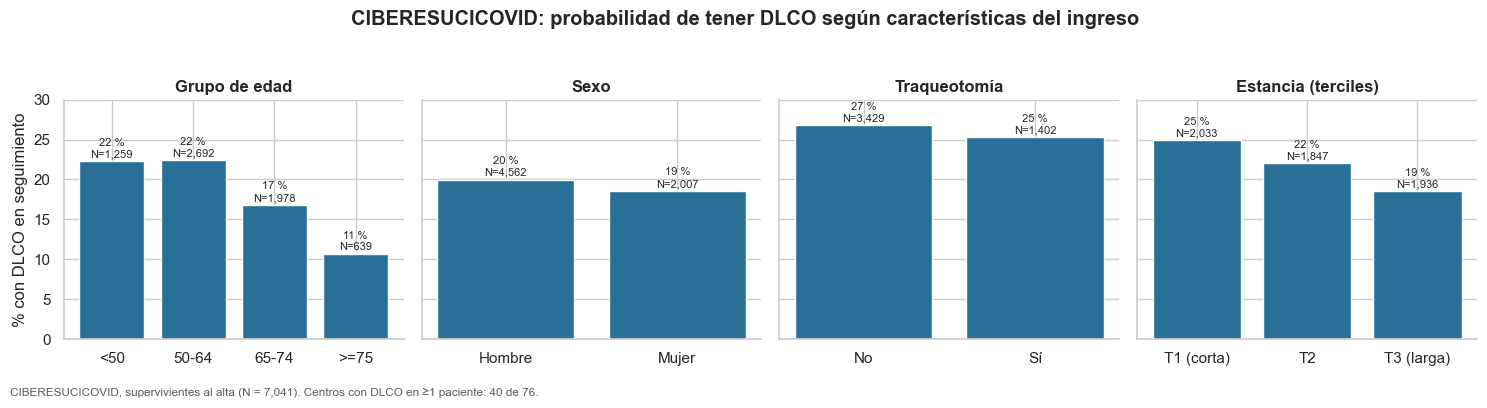

In [12]:
cib = nucleo[nucleo["en_CIBERESUCICOVID"] == 1].copy()
cib = cib[cib["nu_exitus_hosp"] != 1]          # solo supervivientes pueden tener seguimiento
cib["grupo_edad"] = carga.edad_agrupada(cib["edad_tramo5"], cfg["edad_grupos"])
cib["con_dlco"] = cib["nu_dlco_pct_seg"].notna()
cib["estancia_terciles"] = pd.qcut(cib["estancia_hosp_dias"], 3, labels=["T1 (corta)", "T2", "T3 (larga)"])

factores = {"Grupo de edad": "grupo_edad", "Sexo": "sexo", "Traqueotomía": "nu_traqueo",
            "Estancia (terciles)": "estancia_terciles"}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, (titulo, col) in zip(axes, factores.items()):
    g = cib.groupby(col, observed=True)["con_dlco"].agg(["mean", "size"])
    g = g[g["size"] >= N_MIN]
    etiquetas = {"sexo": {0: "Hombre", 1: "Mujer"}, "nu_traqueo": {0: "No", 1: "Sí"}}.get(col, {})
    ax.bar([str(etiquetas.get(i, i)) for i in g.index], 100 * g["mean"], color=COLOR["CIBERESUCICOVID"])
    for i, (m, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, 100 * m + 0.5, f"{100*m:.0f} %\nN={n:,}", ha="center", fontsize=8)
    ax.set_title(titulo); ax.set_xlabel("")
axes[0].set_ylabel("% con DLCO en seguimiento"); axes[0].set_ylim(0, 30)
centros = cib.groupby("centro_id")["con_dlco"].mean()
fig.suptitle("CIBERESUCICOVID: probabilidad de tener DLCO según características del ingreso", y=1.04, fontweight="bold")
nota(axes[0], f"CIBERESUCICOVID, supervivientes al alta (N = {len(cib):,}). "
              f"Centros con DLCO en ≥1 paciente: {(centros > 0).sum()} de {len(centros)}.")
plt.tight_layout(); guardar(fig, "03_sesgo_seleccion_dlco"); plt.show()

- **El centro pesa más que el paciente.** 36 de los 76 centros no registran ninguna DLCO (el 20 % de los supervivientes). Entre los centros con al menos 50 pacientes, la proporción medida va del 0 % al 92 %.
- **El paciente también cuenta, aunque menos.** Se mide menos a los mayores de 75 años (11 % frente a 22 % en los menores de 65) y a quienes tuvieron estancias largas. Los fenotipos de la capa A representarán a supervivientes más jóvenes de centros con laboratorio de función pulmonar.
- **Implicación para el diseño:** el centro es una fuente de heterogeneidad que hay que controlar, y la validación *leave-one-center-out* es imprescindible.

## 4 · Demografía y comorbilidad basal

Tramos originales (ordenados por edad, no alfabéticamente):
['<50', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '40-49', '45-49', '50-54', '50-69', '55-59', '60-64', '60-69', '65-69', '70+', '70-74', '75-79', '80-84', '85-89']


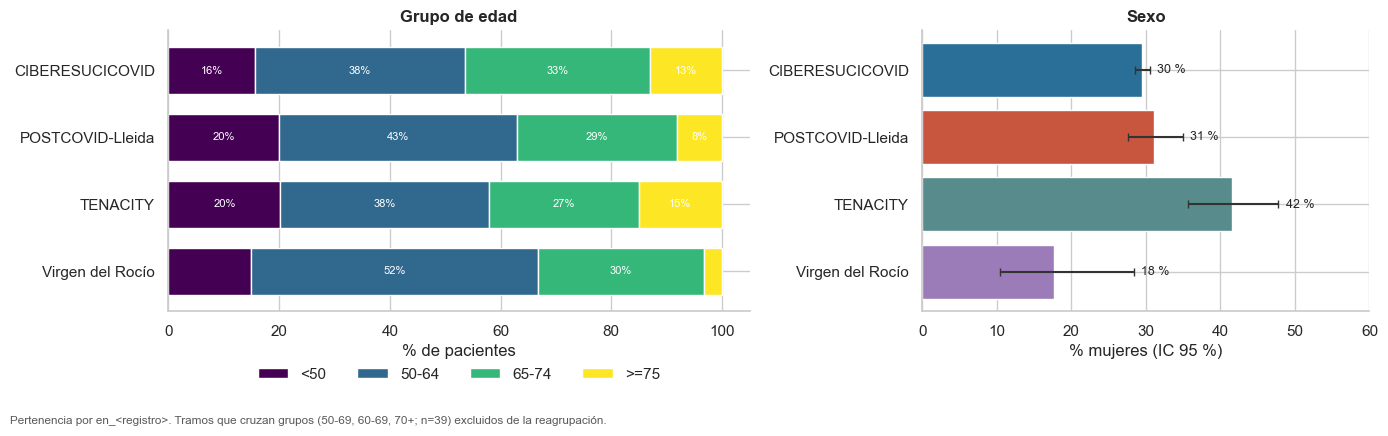

In [13]:
por_registro["grupo_edad"] = carga.edad_agrupada(por_registro["edad_tramo5"], cfg["edad_grupos"])
print("Tramos originales (ordenados por edad, no alfabéticamente):")
print(list(carga.edad_ordenada(nucleo["edad_tramo5"]).categories))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
dist_edad = pd.crosstab(por_registro["registro"], por_registro["grupo_edad"], normalize="index") * 100
dist_edad.index = [ETQ[r] for r in dist_edad.index]
dist_edad.plot.barh(stacked=True, ax=ax, colormap="viridis", width=0.7, edgecolor="white")
n_edad = pd.crosstab(por_registro["registro"], por_registro["grupo_edad"])
for cont, col in zip(ax.containers, dist_edad.columns):
    etiquetas = [f"{v:.0f}%" if n >= N_MIN else "" for v, n in zip(dist_edad[col], n_edad[col])]
    ax.bar_label(cont, labels=etiquetas, label_type="center", fontsize=8, color="white")
ax.invert_yaxis(); ax.set_xlabel("% de pacientes"); ax.set_title("Grupo de edad")
ax.legend(title="", ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False)

ax = axes[1]
mujeres = por_registro.groupby("registro", observed=True)["sexo"].agg(lambda s: (s == 1).sum() / s.notna().sum() * 100)
n_sexo = por_registro.groupby("registro", observed=True)["sexo"].count()
ax.barh([ETQ[r] for r in mujeres.index], mujeres, color=PALETA)
for i, (m, n) in enumerate(zip(mujeres, n_sexo)):
    lo, hi = ic_wilson(int(round(m * n / 100)), n)
    ax.errorbar(m, i, xerr=[[m - lo], [hi - m]], color="0.2", capsize=3)
    ax.text(hi + 1, i, f"{m:.0f} %", va="center", fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 60); ax.set_xlabel("% mujeres (IC 95 %)"); ax.set_title("Sexo")
nota(axes[0], "Pertenencia por en_<registro>. Tramos que cruzan grupos (50-69, 60-69, 70+; n=39) excluidos de la reagrupación.")
plt.tight_layout(); guardar(fig, "04_demografia"); plt.show()

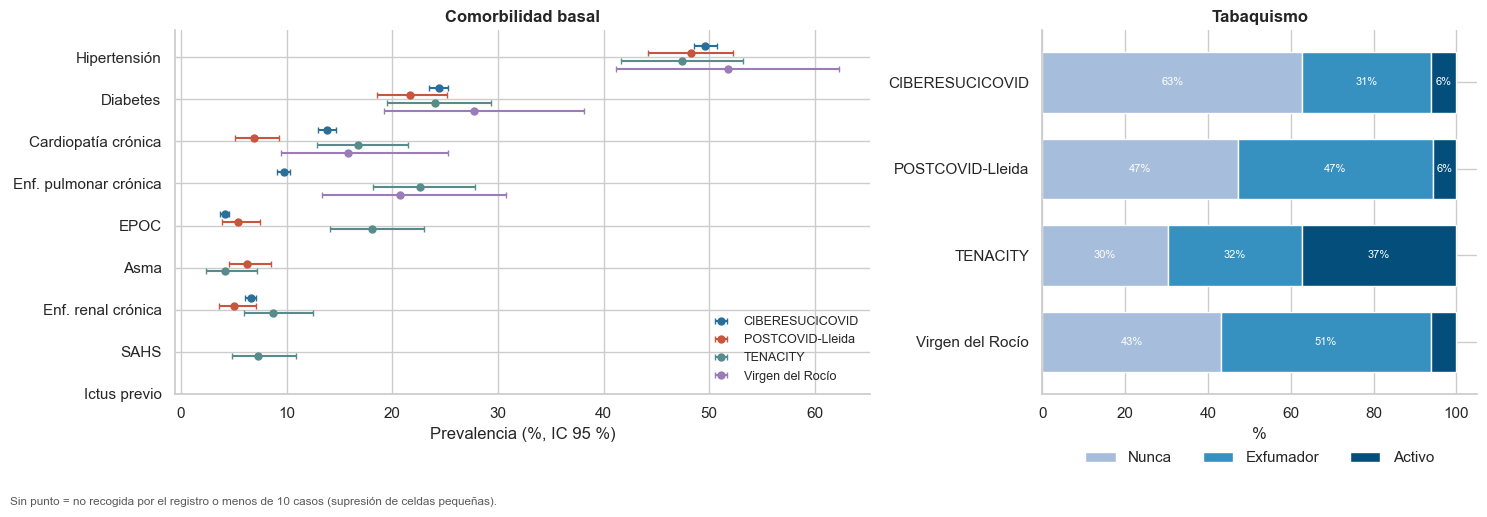

In [14]:
comorb = {"nu_hta": "Hipertensión", "nu_diabetes": "Diabetes", "nu_card_cronica": "Cardiopatía crónica",
          "nu_pulm_cronica": "Enf. pulmonar crónica", "nu_epoc": "EPOC", "nu_asma": "Asma",
          "nu_renal_cronica": "Enf. renal crónica", "nu_sahs": "SAHS", "nu_ictus_previo": "Ictus previo"}
filas = []
for v, nombre in comorb.items():
    for r in REG:
        s = por_registro.loc[por_registro["registro"] == r, v].dropna()
        if recoge.loc[v, r] and len(s) >= N_MIN and s.sum() >= N_MIN:
            lo, hi = ic_wilson(int(s.sum()), len(s))
            filas.append({"comorbilidad": nombre, "registro": ETQ[r], "pct": 100 * s.mean(), "lo": lo, "hi": hi, "n": len(s)})
prev = pd.DataFrame(filas)
tab_cig = pd.crosstab(por_registro["registro"], por_registro["nu_tabaquismo"].map({0: "Nunca", 1: "Activo", 2: "Exfumador"}),
                      normalize="index") * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
orden = list(comorb.values())
desplaz = dict(zip([ETQ[r] for r in REG], np.linspace(-0.27, 0.27, len(REG))))
for r in REG:
    d = prev[prev["registro"] == ETQ[r]]
    ypos = [orden.index(c) + desplaz[ETQ[r]] for c in d["comorbilidad"]]
    ax.errorbar(d["pct"], ypos, xerr=[d["pct"] - d["lo"], d["hi"] - d["pct"]], fmt="o", color=COLOR[r],
                label=ETQ[r], capsize=2, ms=5)
ax.set_yticks(range(len(orden)), orden); ax.invert_yaxis()
ax.set_xlabel("Prevalencia (%, IC 95 %)"); ax.set_title("Comorbilidad basal")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax = axes[1]
tab_cig.index = [ETQ[r] for r in tab_cig.index]
tab_cig[["Nunca", "Exfumador", "Activo"]].plot.barh(stacked=True, ax=ax, color=["#a6bddb", "#3690c0", "#034e7b"], width=0.7)
n_cig = pd.crosstab(por_registro["registro"], por_registro["nu_tabaquismo"].map({0: "Nunca", 1: "Activo", 2: "Exfumador"}))
for cont, col in zip(ax.containers, ["Nunca", "Exfumador", "Activo"]):
    ax.bar_label(cont, labels=[f"{v:.0f}%" if n >= N_MIN else "" for v, n in zip(tab_cig[col], n_cig[col])],
                 label_type="center", fontsize=8, color="white")
ax.invert_yaxis(); ax.set_xlabel("%"); ax.set_title("Tabaquismo")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
nota(axes[0], f"Sin punto = no recogida por el registro o menos de {N_MIN} casos (supresión de celdas pequeñas).")
plt.tight_layout(); guardar(fig, "04_comorbilidad"); plt.show()

**Lectura.**
- **Las cohortes COVID se parecen en edad y sexo:** unos dos tercios son hombres, con pico de 50 a 74 años. Hipertensión y diabetes tienen prevalencias parecidas en los cuatro registros.
- **TENACITY tiene otra casuística:** EPOC en el 18 % y enfermedad pulmonar crónica en el 23 %, frente al 4 % y el 10 % en CIBERESUCICOVID, y un **37 % de fumadores activos**. La cifra coincide con el campo original (`IH_fumador`), así que no es un error de armonización, pero conviene confirmarla con el equipo de TENACITY. Probablemente refleja que TENACITY incluye neumonías y SDRA no COVID.
- **Implicación:** la comorbilidad respiratoria previa puede explicar parte de la peor función pulmonar tras el alta. Es una variable de descripción y un posible confusor al comparar fenotipos entre cohortes.

## 5 · Gravedad del episodio agudo

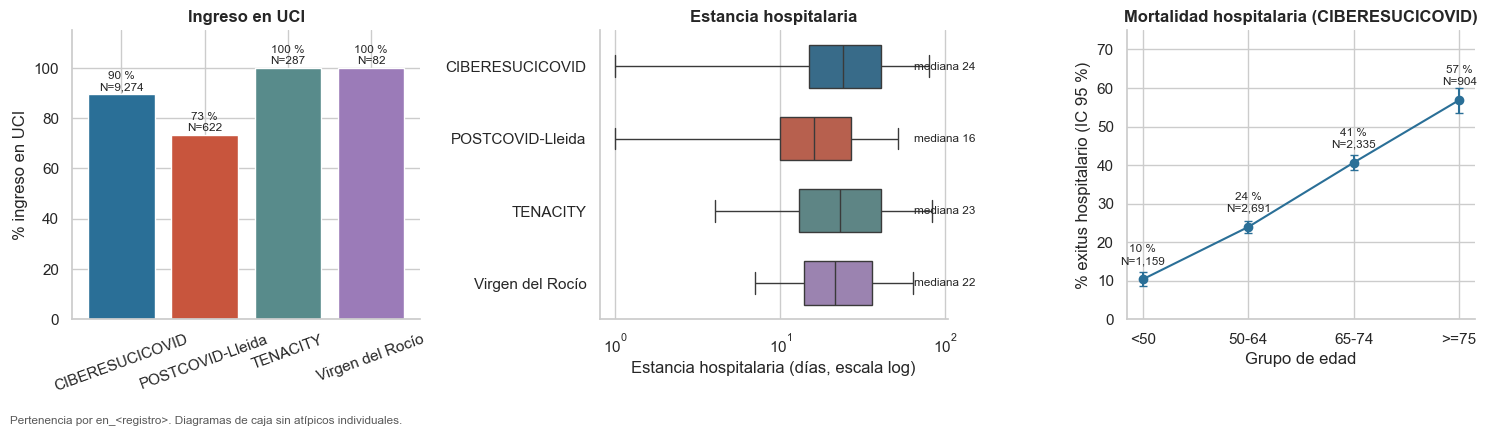

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
uci = por_registro.groupby("registro", observed=True)["nu_ingreso_uci"].agg(["mean", "count"])
ax.bar([ETQ[r] for r in uci.index], 100 * uci["mean"], color=PALETA)
for i, (m, n) in enumerate(zip(uci["mean"], uci["count"])):
    ax.text(i, 100 * m + 1.5, f"{100*m:.0f} %\nN={n:,}", ha="center", fontsize=8.5)
ax.set_ylim(0, 115); ax.set_ylabel("% ingreso en UCI"); ax.set_title("Ingreso en UCI")
ax.tick_params(axis="x", rotation=20)

ax = axes[1]
est = por_registro[por_registro["estancia_hosp_dias"] > 0]
sns.boxplot(data=est, y="registro", x="estancia_hosp_dias", hue="registro", palette=COLOR, showfliers=False,
            ax=ax, legend=False, order=REG, width=0.6)
ax.set_xscale("log"); ax.set_xlabel("Estancia hospitalaria (días, escala log)"); ax.set_ylabel("")
ax.set_yticks(range(len(REG)), [ETQ[r] for r in REG]); ax.set_title("Estancia hospitalaria")
for i, r in enumerate(REG):
    med = est.loc[est["registro"] == r, "estancia_hosp_dias"].median()
    ax.text(est["estancia_hosp_dias"].quantile(0.995), i, f"mediana {med:.0f}", va="center", ha="right", fontsize=8.5)

ax = axes[2]
cib_all = nucleo[nucleo["en_CIBERESUCICOVID"] == 1].copy()
cib_all["grupo_edad"] = carga.edad_agrupada(cib_all["edad_tramo5"], cfg["edad_grupos"])
mort = cib_all.groupby("grupo_edad", observed=True)["nu_exitus_hosp"].agg(["sum", "count"])
pct = 100 * mort["sum"] / mort["count"]
ic = np.array([ic_wilson(int(k), int(n)) for k, n in zip(mort["sum"], mort["count"])])
ax.errorbar(range(len(pct)), pct, yerr=[pct - ic[:, 0], ic[:, 1] - pct], fmt="o-", color=COLOR["CIBERESUCICOVID"], capsize=3)
for i, (p, n) in enumerate(zip(pct, mort["count"])):
    ax.text(i, p + 4, f"{p:.0f} %\nN={n:,}", ha="center", fontsize=8.5)
ax.set_xticks(range(len(pct)), pct.index.astype(str)); ax.set_ylim(0, 75)
ax.set_ylabel("% exitus hospitalario (IC 95 %)"); ax.set_xlabel("Grupo de edad"); ax.set_title("Mortalidad hospitalaria (CIBERESUCICOVID)")
nota(axes[0], "Pertenencia por en_<registro>. Diagramas de caja sin atípicos individuales.")
plt.tight_layout(); guardar(fig, "05_gravedad_aguda"); plt.show()

In [16]:
traq = por_registro.groupby("registro", observed=True)["nu_traqueo"].agg(["sum", "count"])
traq = traq[traq["count"] >= N_MIN]
print("Traqueotomía:", {ETQ[r]: privacidad.proporcion_segura(int(k), int(n), N_MIN) for r, (k, n) in traq.iterrows()})
sdra = por_registro.groupby("registro", observed=True)["nu_sdra"].agg(["sum", "count"])
sdra = sdra[sdra["count"] >= N_MIN]
print("SDRA:", {ETQ[r]: privacidad.proporcion_segura(int(k), int(n), N_MIN) for r, (k, n) in sdra.iterrows()})
muertos_con_seg = int(((nucleo["nu_exitus_hosp"] == 1) & nucleo["nu_dlco_pct_seg"].notna()).sum())
print(f"Exitus hospitalario con DLCO de seguimiento (debería ser 0): {muertos_con_seg}")

Traqueotomía: {'CIBERESUCICOVID': '2090/7047 (29.7 %)', 'POSTCOVID-Lleida': '77/437 (17.6 %)', 'TENACITY': '53/148 (35.8 %)', 'Virgen del Rocío': '14/82 (17.1 %)'}
SDRA: {'CIBERESUCICOVID': '456/459 (99.3 %)', 'POSTCOVID-Lleida': '598/618 (96.8 %)', 'Virgen del Rocío': '80/82 (97.6 %)'}
Exitus hospitalario con DLCO de seguimiento (debería ser 0): 2


**Lectura.**
- Son cohortes de **pacientes graves**: casi todos ingresaron en UCI, salvo un tercio de Lleida (pacientes de planta). Los fenotipos describirán secuelas tras enfermedad crítica, no tras COVID en general.
- Hay 2 pacientes con exitus hospitalario y DLCO de seguimiento: es una inconsistencia que hay que revisar (exitus mal codificado o fusión errónea).
- CIBERESUCICOVID tiene **un 31 % de mortalidad hospitalaria**, con un gradiente muy marcado por edad. La población con seguimiento está seleccionada por supervivencia: hay que restar los exitus antes de calcular cualquier porcentaje de "pacientes con seguimiento".
- Las variables de gravedad (estancia, traqueotomía, UCI) son variables de **descripción y predicción**, no de definición de fenotipo.

## 6 · Momento del seguimiento

Las cohortes no miden en el mismo momento. Si se compara la DLCO "de la primera visita" sin tener en cuenta `visita_dias`, se mezclan pacientes a 1 mes con pacientes a 5 meses.

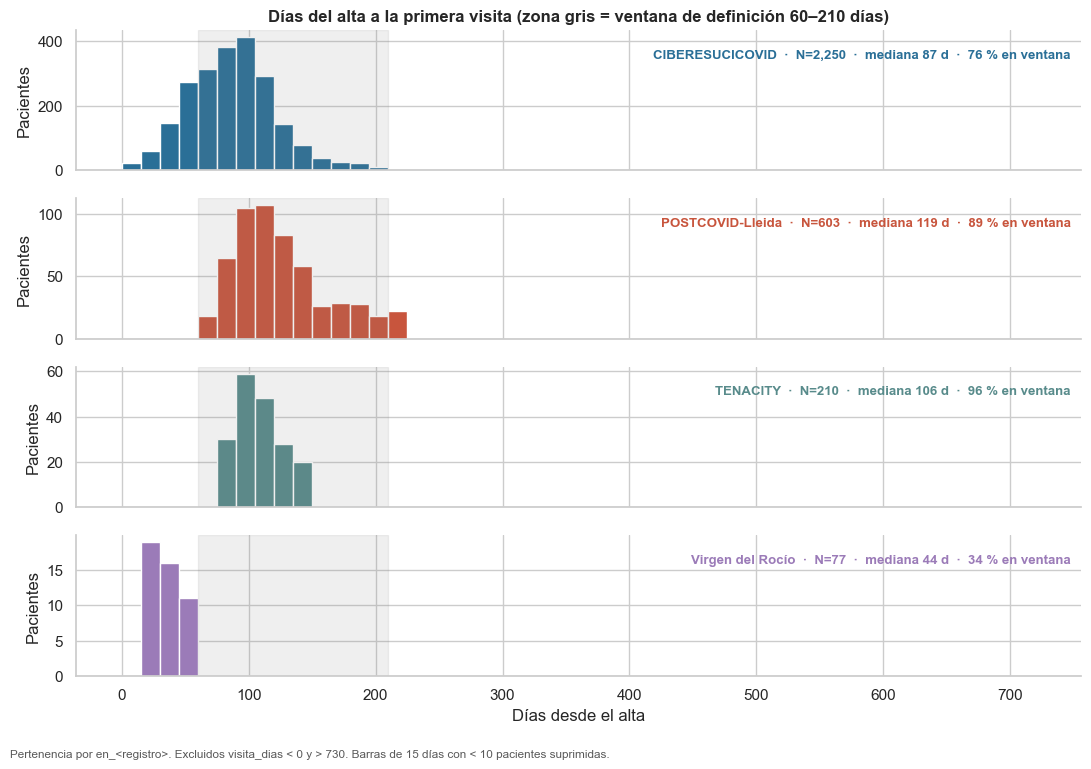

In [17]:
v0, v1 = cfg["tiempo"]["ventana_definicion_dias"]
vd = por_registro[(por_registro["visita_dias"] >= 0) & (por_registro["visita_dias"] <= 730)]

fig, axes = plt.subplots(len(REG), 1, figsize=(11, 7.5), sharex=True)
for ax, r in zip(axes, REG):
    s = vd.loc[vd["registro"] == r, "visita_dias"]
    cuentas, bordes = np.histogram(s, bins=np.arange(0, 731, 15))
    cuentas = np.where(cuentas >= N_MIN, cuentas, 0)          # barras con < N_MIN pacientes no se dibujan
    ax.bar(bordes[:-1], cuentas, width=15, align="edge", color=COLOR[r], edgecolor="white")
    ax.axvspan(v0, v1, color="0.5", alpha=0.12)
    dentro = ((s >= v0) & (s <= v1)).mean() * 100
    ax.text(0.99, 0.8, f"{ETQ[r]}  ·  N={len(s):,}  ·  mediana {s.median():.0f} d  ·  {dentro:.0f} % en ventana",
            transform=ax.transAxes, ha="right", fontsize=9.5, fontweight="bold", color=COLOR[r])
    ax.set_ylabel("Pacientes")
axes[0].set_title(f"Días del alta a la primera visita (zona gris = ventana de definición {v0}–{v1} días)")
axes[-1].set_xlabel("Días desde el alta")
nota(axes[-1], f"Pertenencia por en_<registro>. Excluidos visita_dias < 0 y > 730. Barras de 15 días con < {N_MIN} pacientes suprimidas.")
plt.tight_layout(); guardar(fig, "06_visita_dias"); plt.show()

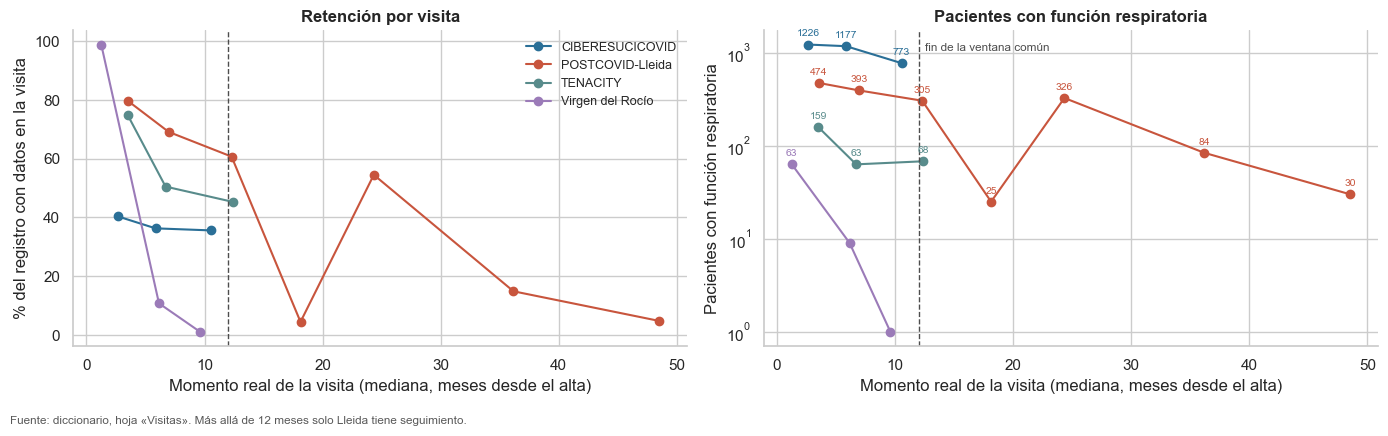

In [18]:
vis = dic["visitas"].copy()
vis.columns = ["registro", "visita", "mes_nominal", "mes_real", "pacientes", "pct_registro", "con_func_resp", "n_variables"]
vis = vis.dropna(subset=["registro"])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for r_dic, r in zip(["CIBERESUCICOVID", "POSTCOVID-Lleida", "TENACITY", "Virgen del Rocío"], REG):
    d = vis[vis["registro"] == r_dic]
    axes[0].plot(d["mes_real"], d["pct_registro"], "o-", color=COLOR[r], label=ETQ[r])
    axes[1].plot(d["mes_real"], d["con_func_resp"], "o-", color=COLOR[r], label=ETQ[r])
    for x, y, n in zip(d["mes_real"], d["con_func_resp"], d["con_func_resp"]):
        if n >= N_MIN:
            axes[1].annotate(f"{int(n)}", (x, y), textcoords="offset points", xytext=(0, 6), fontsize=7.5, ha="center", color=COLOR[r])
for ax in axes:
    ax.axvline(cfg["tiempo"]["ventana_comun_meses"], color="0.3", ls="--", lw=1)
    ax.set_xlabel("Momento real de la visita (mediana, meses desde el alta)")
axes[0].set_ylabel("% del registro con datos en la visita"); axes[0].set_title("Retención por visita")
axes[1].set_ylabel("Pacientes con función respiratoria"); axes[1].set_yscale("log"); axes[1].set_title("Pacientes con función respiratoria")
axes[0].legend(frameon=False, fontsize=9)
axes[1].text(cfg["tiempo"]["ventana_comun_meses"] + 0.5, axes[1].get_ylim()[1] * 0.6, "fin de la ventana común", fontsize=8.5, color="0.3")
nota(axes[0], "Fuente: diccionario, hoja «Visitas». Más allá de 12 meses solo Lleida tiene seguimiento.")
plt.tight_layout(); guardar(fig, "06_retencion_visitas"); plt.show()

**Lectura.**
- Virgen del Rocío mide al **mes** y el resto a los **3–4 meses**. La ventana de definición (60–210 días) recoge al 76–96 % de CIBERESUCICOVID, Lleida y TENACITY, pero solo a un tercio de Virgen del Rocío, lo que confirma su papel complementario.
- La retención cae rápido: en CIBERESUCICOVID, los pacientes con función respiratoria pasan de 1.226 a los 3 meses a 773 al año. La ventana común termina a los **12 meses**; lo posterior es solo Lleida.

## 7 · Función pulmonar, esfuerzo y disnea en la primera visita

Son las variables armonizadas del núcleo (`nu_*_seg`), medidas en la **primera** visita de seguimiento de cada registro.

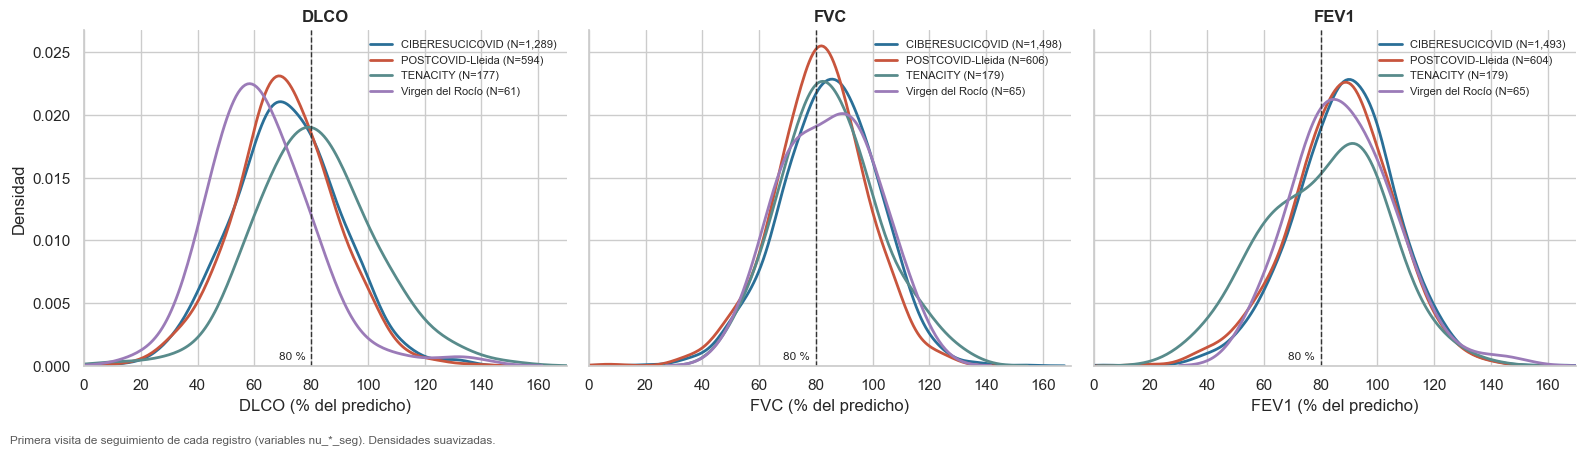

In [19]:
fun = {"nu_dlco_pct_seg": ("DLCO", UMB["dlco_pct"]), "nu_fvc_pct_seg": ("FVC", UMB["fvc_pct"]),
       "nu_fev1_pct_seg": ("FEV1", UMB["fev1_pct"])}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for ax, (v, (nombre, u)) in zip(axes, fun.items()):
    for r in REG:
        s = por_registro.loc[por_registro["registro"] == r, v].dropna()
        if len(s) >= N_MIN:
            sns.kdeplot(s, ax=ax, color=COLOR[r], lw=2, label=f"{ETQ[r]} (N={len(s):,})", clip=(0, 170), bw_adjust=1.2)
    ax.axvline(u, color="0.2", ls="--", lw=1); ax.text(u - 2, ax.get_ylim()[1] * 0.02, f"{u} %", ha="right", fontsize=8.5)
    ax.set_xlabel(f"{nombre} (% del predicho)"); ax.set_title(nombre); ax.set_xlim(0, 170)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Densidad")
nota(axes[0], "Primera visita de seguimiento de cada registro (variables nu_*_seg). Densidades suavizadas.")
plt.tight_layout(); guardar(fig, "07_funcion_pulmonar_distribucion"); plt.show()

In [20]:
filas = []
for v, (nombre, u) in fun.items():
    for r in REG:
        s = por_registro.loc[por_registro["registro"] == r, v].dropna()
        if len(s) < N_MIN:
            continue
        k = int((s < u).sum()); lo, hi = ic_wilson(k, len(s))
        filas.append({"prueba": nombre, "registro": ETQ[r], "N": len(s), "mediana": s.median(),
                      "P25–P75": f"{s.quantile(.25):.0f}–{s.quantile(.75):.0f}",
                      f"% < umbral": round(100 * k / len(s), 1), "IC 95 %": f"{lo:.1f}–{hi:.1f}"})
tabla_func = pd.DataFrame(filas).set_index(["prueba", "registro"])
tabla_func.to_csv(TAB / "07_funcion_pulmonar_primera_visita.csv")
tabla_func

N  mediana P25–P75  % < umbral    IC 95 %
prueba registro                                                      
DLCO   CIBERESUCICOVID   1289    71.00   59–83        67.4  64.8–69.9
       POSTCOVID-Lleida   594    70.00   60–82        70.2  66.4–73.7
       TENACITY           177    80.00   68–93        49.2  41.9–56.5
       Virgen del Rocío    61    60.00   51–73        86.9  76.2–93.2
FVC    CIBERESUCICOVID   1498    85.00   73–96        36.8  34.4–39.3
       POSTCOVID-Lleida   606    81.25   71–92        43.4  39.5–47.4
       TENACITY           179    84.00   74–95        38.5  31.7–45.8
       Virgen del Rocío    65    85.00   71–96        41.5  30.4–53.7
FEV1   CIBERESUCICOVID   1493    89.00  77–100        29.0  26.8–31.4
       POSTCOVID-Lleida   604    88.30   76–99        31.1  27.6–34.9
       TENACITY           179    84.00   66–96        43.0  36.0–50.3
       Virgen del Rocío    65    87.00   77–98        32.3  22.2–44.4

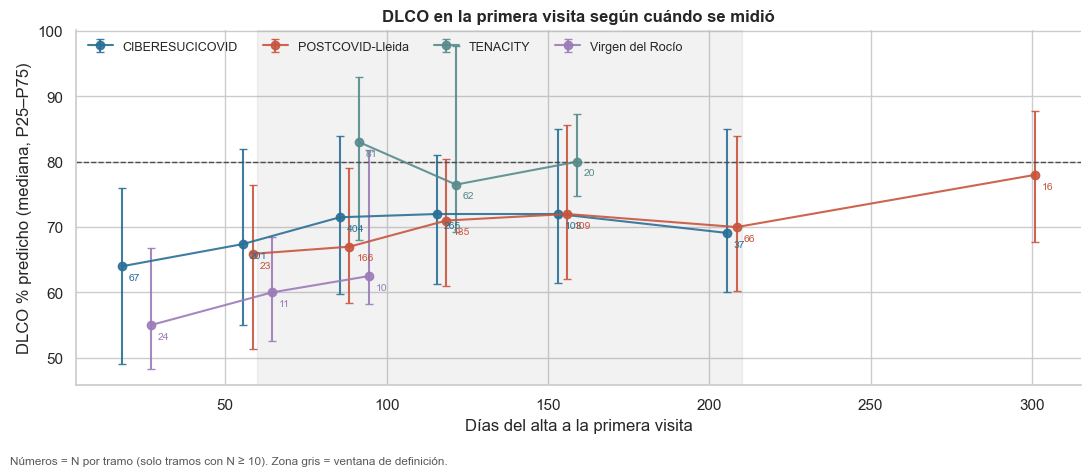

In [21]:
# DLCO según el momento de la visita: ¿las diferencias entre registros son de cohorte o de tiempo?
d = por_registro[por_registro["nu_dlco_pct_seg"].notna() & (por_registro["visita_dias"] >= 0)].copy()
d["tramo"] = pd.cut(d["visita_dias"], [0, 45, 75, 105, 135, 180, 240, 365], right=False)
g = d.groupby(["registro", "tramo"], observed=True)["nu_dlco_pct_seg"].agg(["median", "count",
        lambda s: s.quantile(.25), lambda s: s.quantile(.75)])
g.columns = ["mediana", "n", "p25", "p75"]; g = g[g["n"] >= N_MIN].reset_index()
g["x"] = [(i.left + i.right) / 2 for i in g["tramo"]]

fig, ax = plt.subplots(figsize=(11, 4.6))
for i, r in enumerate(REG):
    s = g[g["registro"] == r]
    x = s["x"] + (i - 1.5) * 3
    ax.errorbar(x, s["mediana"], yerr=[s["mediana"] - s["p25"], s["p75"] - s["mediana"]], fmt="o-", color=COLOR[r],
                capsize=3, label=ETQ[r], alpha=0.9)
    for xx, yy, n in zip(x, s["mediana"], s["n"]):
        ax.annotate(f"{n}", (xx, yy), textcoords="offset points", xytext=(5, -10), fontsize=7.5, color=COLOR[r])
ax.axhline(UMB["dlco_pct"], color="0.3", ls="--", lw=1)
ax.axvspan(v0, v1, color="0.5", alpha=0.1)
ax.set_xlabel("Días del alta a la primera visita"); ax.set_ylabel("DLCO % predicho (mediana, P25–P75)")
ax.set_title("DLCO en la primera visita según cuándo se midió")
ax.legend(frameon=False, ncol=4, fontsize=9, loc="upper left")
nota(ax, "Números = N por tramo (solo tramos con N ≥ 10). Zona gris = ventana de definición.")
plt.tight_layout(); guardar(fig, "07_dlco_vs_visita_dias"); plt.show()

- **El momento de la medida explica parte de la diferencia.** En CIBERESUCICOVID, la mediana de DLCO sube de 64 % (< 45 días) a 72 % (105–180 días). Comparar registros que miden en momentos distintos mezcla tiempo y cohorte.
- **Pero no la explica toda.** En el mismo tramo de 75–105 días, TENACITY sigue unos 10 puntos por encima (83 % frente a 67–72 %). Es una diferencia real de cohorte: pospandémica, no solo COVID y con otra casuística.
- **Implicación:** la definición de fenotipo tiene que usar una ventana temporal común y **umbrales clínicos**. Unos z-scores por cohorte borrarían precisamente esta diferencia real, y un fenotipo "replicado" en TENACITY tendrá con toda probabilidad otro tamaño relativo.

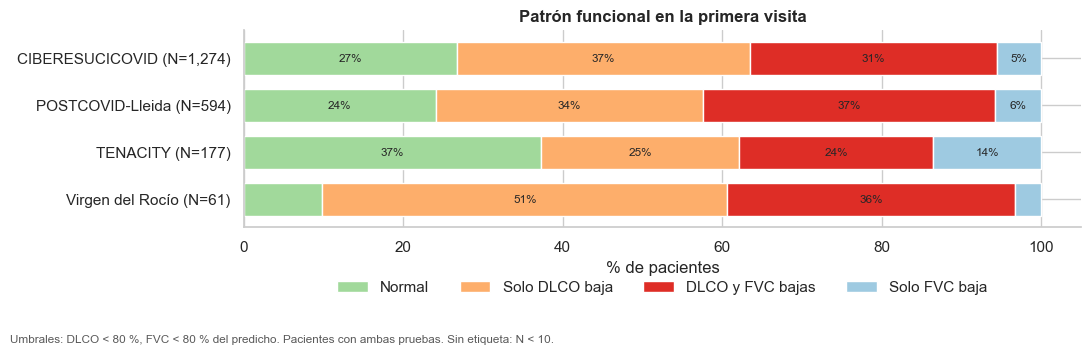

In [22]:
# Patrón de alteración funcional: difusión frente a volumen
pat = por_registro.dropna(subset=["nu_dlco_pct_seg", "nu_fvc_pct_seg"]).copy()
dl = pat["nu_dlco_pct_seg"] < UMB["dlco_pct"]; fv = pat["nu_fvc_pct_seg"] < UMB["fvc_pct"]
pat["patrón"] = np.select([~dl & ~fv, dl & ~fv, dl & fv, ~dl & fv],
                          ["Normal", "Solo DLCO baja", "DLCO y FVC bajas", "Solo FVC baja"], default="")
orden_pat = ["Normal", "Solo DLCO baja", "DLCO y FVC bajas", "Solo FVC baja"]
tp = pd.crosstab(pat["registro"], pat["patrón"], normalize="index")[orden_pat] * 100
n_pat = pat.groupby("registro", observed=True).size()
tp.index = [f"{ETQ[r]} (N={n_pat[r]:,})" for r in tp.index]

fig, ax = plt.subplots(figsize=(11, 3.4))
tp.plot.barh(stacked=True, ax=ax, color=["#a1d99b", "#fdae6b", "#de2d26", "#9ecae1"], width=0.7, edgecolor="white")
n_tp = pd.crosstab(pat["registro"], pat["patrón"])[orden_pat]
for cont, col in zip(ax.containers, orden_pat):
    ax.bar_label(cont, labels=[f"{v:.0f}%" if n >= N_MIN else "" for v, n in zip(tp[col], n_tp[col])],
                 label_type="center", fontsize=8.5)
ax.invert_yaxis(); ax.set_xlabel("% de pacientes"); ax.set_title("Patrón funcional en la primera visita")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.2), frameon=False)
nota(ax, f"Umbrales: DLCO < {UMB['dlco_pct']} %, FVC < {UMB['fvc_pct']} % del predicho. Pacientes con ambas pruebas. "
         f"Sin etiqueta: N < {N_MIN}.")
plt.tight_layout(); guardar(fig, "07_patron_funcional"); plt.show()

- **La DLCO baja domina.** Aislada o junto con FVC baja, afecta a dos de cada tres pacientes en CIBERESUCICOVID y Lleida, y la FVC baja aislada es rara (≈ 5 %). El gradiente normal → difusión → difusión y volumen es un primer candidato a eje de fenotipos respiratorios.
- **TENACITY se aparta del resto:** más pacientes normales y más FVC baja aislada (14 %). Encaja con su casuística: el 18 % tiene EPOC y el 23 % enfermedad pulmonar crónica, frente al 4 % y el 10 % en CIBERESUCICOVID (§4).

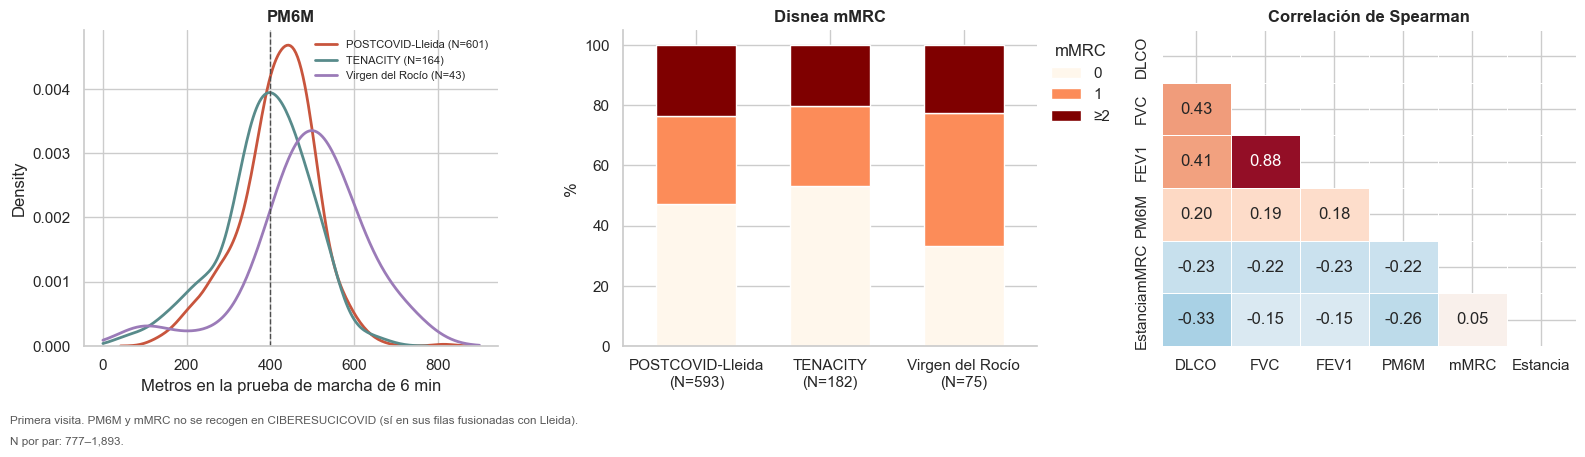

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
regs_b = ["POSTCOVID_LLEIDA", "TENACITY", "VIRGEN_DEL_ROCIO"]
ax = axes[0]
for r in regs_b:
    s = por_registro.loc[por_registro["registro"] == r, "nu_pm6m_metros_seg"].dropna()
    sns.kdeplot(s, ax=ax, color=COLOR[r], lw=2, label=f"{ETQ[r]} (N={len(s)})", clip=(0, 900))
ax.axvline(UMB["pm6m_metros"], color="0.3", ls="--", lw=1)
ax.set_xlabel("Metros en la prueba de marcha de 6 min"); ax.set_title("PM6M"); ax.legend(frameon=False, fontsize=8)

ax = axes[1]
mmrc_cat = por_registro["nu_disnea_mmrc_seg"].map({0: "0", 1: "1", 2: "≥2", 3: "≥2", 4: "≥2"})
mm = pd.crosstab(por_registro["registro"], mmrc_cat, normalize="index").loc[regs_b, ["0", "1", "≥2"]] * 100
n_mm = por_registro.groupby("registro", observed=True)["nu_disnea_mmrc_seg"].count()
mm.index = [f"{ETQ[r]}\n(N={n_mm[r]})" for r in mm.index]
mm.plot.bar(stacked=True, ax=ax, colormap="OrRd", width=0.6, edgecolor="white")
ax.set_ylabel("%"); ax.set_title("Disnea mMRC"); ax.tick_params(axis="x", rotation=0)
ax.legend(title="mMRC", bbox_to_anchor=(1, 1), frameon=False)

ax = axes[2]
seg = ["nu_dlco_pct_seg", "nu_fvc_pct_seg", "nu_fev1_pct_seg", "nu_pm6m_metros_seg", "nu_disnea_mmrc_seg", "estancia_hosp_dias"]
nombres = ["DLCO", "FVC", "FEV1", "PM6M", "mMRC", "Estancia"]
corr = nucleo[seg].corr(method="spearman"); corr.index = corr.columns = nombres
npar = nucleo[seg].notna().astype(int).T @ nucleo[seg].notna().astype(int)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, cbar=False, linewidths=0.5)
ax.set_title("Correlación de Spearman")
nota(axes[0], "Primera visita. PM6M y mMRC no se recogen en CIBERESUCICOVID (sí en sus filas fusionadas con Lleida).")
nota(ax, f"N por par: {int(npar.values[np.tril_indices(6, -1)].min())}–{int(npar.values[np.tril_indices(6, -1)].max()):,}.")
plt.tight_layout(); guardar(fig, "07_esfuerzo_disnea_correlaciones"); plt.show()

**Lectura.**
- FVC y FEV1 están muy correlacionadas (redundantes). Para el clustering conviene usar una de las dos, o el cociente.
- La DLCO apenas se correlaciona con la PM6M (ρ = 0,20) y con la disnea (ρ = −0,23): **la función pulmonar, el esfuerzo y los síntomas son dominios casi independientes**. Ahí está el interés del fenotipado multidominio (capa B). También es una advertencia: con correlaciones tan bajas, los clústeres pueden salir poco separados (siluetas bajas).
- La estancia hospitalaria es la variable aguda más asociada a la DLCO (ρ = −0,33). La mediana baja de 78 % con estancias < 14 días a 55 % con ≥ 60 días, así que es la que más promete como predictor.

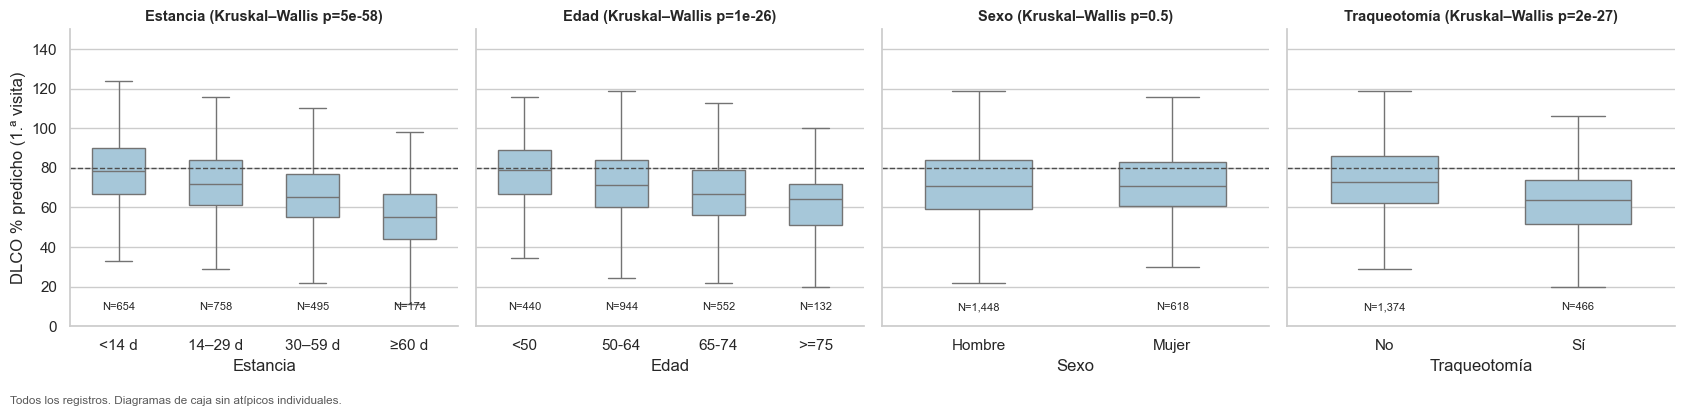

In [24]:
# DLCO según gravedad del ingreso (variables de descripción, no de definición)
d = por_registro[por_registro["nu_dlco_pct_seg"].notna()].copy()
d["Estancia"] = pd.cut(d["estancia_hosp_dias"], [0, 14, 30, 60, 400], labels=["<14 d", "14–29 d", "30–59 d", "≥60 d"])
d["Edad"] = d["grupo_edad"]
d["Sexo"] = d["sexo"].map({0: "Hombre", 1: "Mujer"})
d["Traqueotomía"] = d["nu_traqueo"].map({0: "No", 1: "Sí"})
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharey=True)
for ax, col in zip(axes, ["Estancia", "Edad", "Sexo", "Traqueotomía"]):
    dd = d.dropna(subset=[col])
    sns.boxplot(data=dd, x=col, y="nu_dlco_pct_seg", ax=ax, showfliers=False, color="#9ecae1", width=0.55)
    for i, (k, n) in enumerate(dd.groupby(col, observed=True).size().items()):
        ax.text(i, 8, f"N={n:,}", ha="center", fontsize=8)
    ax.axhline(UMB["dlco_pct"], color="0.3", ls="--", lw=1); ax.set_xlabel(col); ax.set_ylabel("")
    rho = stats.kruskal(*[g["nu_dlco_pct_seg"].values for _, g in dd.groupby(col, observed=True)])
    ax.set_title(f"{col} (Kruskal–Wallis p={rho.pvalue:.1g})", fontsize=10.5)
axes[0].set_ylabel("DLCO % predicho (1.ª visita)"); axes[0].set_ylim(0, 150)
nota(axes[0], "Todos los registros. Diagramas de caja sin atípicos individuales.")
plt.tight_layout(); guardar(fig, "07_dlco_por_gravedad"); plt.show()

## 8 · Trayectorias de DLCO

Se construye una **tabla larga** con todas las DLCO (% predicho) de la tabla completa: una fila por paciente, registro y visita. El tiempo es la **fecha real de la prueba menos la fecha de alta** (las fechas están desplazadas por paciente, pero los intervalos son exactos). No se usa el número de visita.

In [25]:
dlco = carga.dlco_larga(cfg, nucleo)
lo_p, hi_p = cfg["calidad"]["dlco_plausible"]
fuera = (dlco["dlco"] < lo_p) | (dlco["dlco"] > hi_p)
neg = dlco["dias_alta"] < 0
print(f"Medidas de DLCO: {len(dlco):,} en {dlco['subject_id'].nunique():,} pacientes")
print(f"Pacientes con ≥2 medidas: {(dlco.groupby('subject_id').size() >= 2).sum():,}")
print(f"Medidas fuera de rango plausible [{lo_p}, {hi_p}]: {int(fuera.sum())}  ·  con fecha anterior al alta: {int(neg.sum())}")
print(f"Medidas sin fecha (solo mes nominal): {int(dlco['dias_alta'].isna().sum())}")
dlco = dlco[~fuera & ~neg].copy()

resumen_vis = dlco.groupby(["registro", "visita"], observed=True).agg(
    N=("dlco", "size"), mes_nominal=("mes_nominal", "first"),
    meses_reales_mediana=("meses_alta", "median"), DLCO_mediana=("dlco", "median")).round(1)
resumen_vis = resumen_vis.sort_values(["registro", "mes_nominal"])
privacidad.suprimir_celdas(resumen_vis.rename(index=ETQ, level=0), N_MIN, ["N"])

Medidas de DLCO: 4,546 en 2,397 pacientes
Pacientes con ≥2 medidas: 1,115
Medidas fuera de rango plausible [20, 160]: 11  ·  con fecha anterior al alta: 42
Medidas sin fecha (solo mes nominal): 24


N  mes_nominal  meses_reales_mediana  DLCO_mediana
registro         visita                                                      
CIBERESUCICOVID  M3      988            3                   3.0          70.4
                 M6      929            6                   5.8          72.0
                 A1      639           12                  10.9          75.0
POSTCOVID-Lleida LV1     461            3                   3.2          70.0
                 LV2     381            6                   6.6          71.0
                 LA1     295           12                  12.1          75.0
                 LM18     24           18                  17.8          68.0
                 LM24    323           24                  24.1          81.0
                 LA3      83           36                  35.9          83.0
                 LA4      30           48                  48.2          81.5
TENACITY         M3      154            3                   3.3          80.5
                 M6       59            6                   6.6          85.0
                 A1       66           12                  12.2          86.5
Virgen del Rocío V1       55            1                   2.8          62.0
                 V2      <10            6                   6.9          69.0

In [26]:
# Pacientes fusionados (CIBERESUCICOVID + Lleida): ¿la misma prueba aparece dos veces?
fus = dlco[dlco["fusionada_lleida"] == 1]
ancho = fus.pivot_table(index="subject_id", columns="visita", values="dlco", aggfunc="first")
comp = ancho[["M3", "LV1"]].dropna() if {"M3", "LV1"} <= set(ancho.columns) else pd.DataFrame()
print(f"Fusionados con DLCO en CIBERESUCICOVID-M3 y Lleida-LV1: {len(comp)}")
if len(comp) >= N_MIN:
    print(f"  Valores idénticos (±1 punto): {100 * (abs(comp['M3'] - comp['LV1']) <= 1).mean():.0f} %")
print("Medidas por fuente en pacientes fusionados:", fus.groupby("registro", observed=True).size().to_dict())

Fusionados con DLCO en CIBERESUCICOVID-M3 y Lleida-LV1: 130
  Valores idénticos (±1 punto): 97 %
Medidas por fuente en pacientes fusionados: {'CIBERESUCICOVID': 295, 'POSTCOVID_LLEIDA': 1216}


En los pacientes fusionados, **la DLCO de CIBERESUCICOVID y la de Lleida son la misma prueba registrada dos veces**. En trayectorias, cada prueba tiene que contar una sola vez por paciente. Para la replicación, estos pacientes se asignan a un único lado.

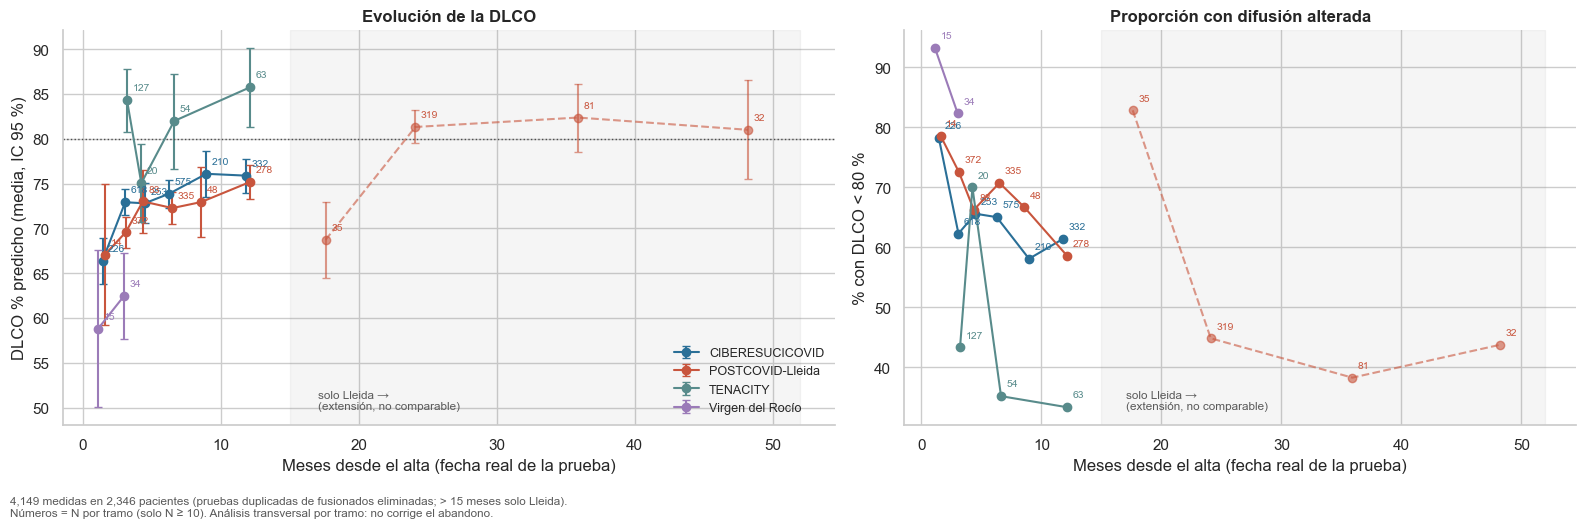

In [27]:
# Una prueba por paciente y momento: en fusionados nos quedamos con la fuente Lleida (más visitas, misma prueba)
dlco_u = dlco[~((dlco["fusionada_lleida"] == 1) & (dlco["registro"] == "CIBERESUCICOVID"))].copy()
cortes = cfg["tiempo"]["cortes_meses"]
dlco_u = dlco_u[dlco_u["meses_alta"].notna()]
dlco_u["tramo"] = pd.cut(dlco_u["meses_alta"], cortes, right=False)

def resumen_tramo(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby(["registro", "tramo"], observed=True).agg(
        n=("dlco", "size"), media=("dlco", "mean"), de=("dlco", "std"),
        mes=("meses_alta", "median"), bajos=("dlco", lambda s: (s < UMB["dlco_pct"]).sum())).reset_index()
    g["ic"] = 1.96 * g["de"] / np.sqrt(g["n"])
    g["pct_bajo"] = (100 * g["bajos"] / g["n"]).where(g["bajos"] >= N_MIN)
    return g[g["n"] >= N_MIN]

# Más allá de la ventana común (con margen: la visita "anual" real llega a ~15 meses) solo se dibuja Lleida
lim_comun = cfg["tiempo"]["ventana_comun_meses"] + 3
dlco_graf = dlco_u[(dlco_u["registro"] == "POSTCOVID_LLEIDA") | (dlco_u["meses_alta"] < lim_comun)]
g = resumen_tramo(dlco_graf)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.15, 1]})
for ax, var, ylab in [(axes[0], "media", "DLCO % predicho (media, IC 95 %)"), (axes[1], "pct_bajo", f"% con DLCO < {UMB['dlco_pct']} %")]:
    for r in REG:
        s = g[g["registro"] == r]
        if s.empty:
            continue
        com, ext = s[s["mes"] <= lim_comun], s[s["mes"] > lim_comun]
        kw = dict(color=COLOR[r], capsize=3, ms=6)
        if var == "media":
            ax.errorbar(com["mes"], com[var], yerr=com["ic"], fmt="o-", label=ETQ[r], **kw)
            if len(ext):
                ax.errorbar(ext["mes"], ext[var], yerr=ext["ic"], fmt="o--", alpha=0.6, **kw)
        else:
            ax.plot(com["mes"], com[var], "o-", color=COLOR[r], label=ETQ[r], ms=6)
            if len(ext):
                ax.plot(ext["mes"], ext[var], "o--", color=COLOR[r], alpha=0.6, ms=6)
        for x, y, n in zip(s["mes"], s[var], s["n"]):
            ax.annotate(f"{n}", (x, y), textcoords="offset points", xytext=(4, 7), fontsize=7.5, color=COLOR[r])
    ax.axvspan(lim_comun, 52, color="0.5", alpha=0.08)
    ax.text(0.33, 0.04, "solo Lleida →\n(extensión, no comparable)", transform=ax.transAxes, fontsize=8.5, color="0.35")
    ax.set_xlabel("Meses desde el alta (fecha real de la prueba)"); ax.set_ylabel(ylab)
axes[0].axhline(UMB["dlco_pct"], color="0.3", ls=":", lw=1)
axes[0].set_title("Evolución de la DLCO"); axes[1].set_title("Proporción con difusión alterada")
axes[0].legend(frameon=False, fontsize=9, loc="lower right")
n_pac = dlco_graf["subject_id"].nunique()
nota(axes[0], f"{len(dlco_graf):,} medidas en {n_pac:,} pacientes (pruebas duplicadas de fusionados eliminadas; > {lim_comun} meses solo Lleida).\n"
              f"Números = N por tramo (solo N ≥ {N_MIN}). Análisis transversal por tramo: no corrige el abandono.")
plt.tight_layout(); guardar(fig, "08_trayectoria_dlco"); plt.show()

**Lectura.**
- **Primer año:** la DLCO media mejora en CIBERESUCICOVID (66 % → 76 %) y en Lleida (67 % → 75 %). TENACITY parte más alto (~84 %) y se mantiene. Aun así, al año **más de la mitad** de los pacientes medidos de CIBERESUCICOVID y Lleida siguen con DLCO < 80 %.
- **Más allá del año (solo Lleida):** la media sigue subiendo, hasta ~81 % a los 2–3 años. Pero cada punto de esta figura corresponde a **otro conjunto de pacientes**: si los que mejoran dejan de acudir, la curva poblacional está sesgada. Lo siguiente comprueba si es así.

In [28]:
# Cambio individual entre la 1.ª medida (ventana de definición) y la medida al año
a0, a1 = cfg["tiempo"]["ventana_anual_dias"]
prim = (dlco_u[(dlco_u["dias_alta"] >= v0) & (dlco_u["dias_alta"] <= v1)]
        .sort_values("dias_alta").groupby(["subject_id", "registro"], observed=True).first().reset_index())
anual = (dlco_u[(dlco_u["dias_alta"] >= a0) & (dlco_u["dias_alta"] <= a1)]
         .sort_values("dias_alta").groupby(["subject_id", "registro"], observed=True).first().reset_index())
par = prim.merge(anual[["subject_id", "registro", "dlco"]], on=["subject_id", "registro"], how="left", suffixes=("_ini", "_anual"))
par["con_anual"] = par["dlco_anual"].notna()

# TENACITY sigue reclutando: separar "abandono" de "aún no le toca"
fechas_ten = carga.cargar_columnas_completa(cfg, ["M3_fecha_visita", "M6_fecha_visita", "A1_fecha_visita"])
corte_ten = pd.to_datetime(fechas_ten.drop(columns="subject_id").stack(), errors="coerce").max()
alta = nucleo.set_index("subject_id")["nu_fecha_alta"]
par["alta"] = par["subject_id"].map(alta)
par["no_le_toca"] = (par["registro"] == "TENACITY") & (par["alta"] + pd.Timedelta(days=a1) > corte_ten)
print(f"Fecha aproximada de corte de TENACITY (última visita registrada, ±30 d): {corte_ten:%Y-%m}")
print(f"TENACITY con 1.ª DLCO en ventana: {int((par['registro'] == 'TENACITY').sum())}, "
      f"de ellos todavía sin visita anual por calendario: {int(par['no_le_toca'].sum())}")
par_ev = par[~par["no_le_toca"]]

filas = []
for r in REG:
    s = par_ev[par_ev["registro"] == r]
    a, b = s.loc[s["con_anual"], "dlco_ini"], s.loc[~s["con_anual"], "dlco_ini"]
    if min(len(a), len(b)) < N_MIN:
        continue
    filas.append({"registro": ETQ[r], "con medida anual (N)": len(a), "DLCO inicial · vuelven": round(a.mean(), 1),
                  "sin medida anual (N)": len(b), "DLCO inicial · no vuelven": round(b.mean(), 1),
                  "diferencia": round(a.mean() - b.mean(), 1), "p (Mann-Whitney)": f"{stats.mannwhitneyu(a, b).pvalue:.2g}"})
tabla_abandono = pd.DataFrame(filas).set_index("registro")
tabla_abandono

Fecha aproximada de corte de TENACITY (última visita registrada, ±30 d): 2026-07
TENACITY con 1.ª DLCO en ventana: 156, de ellos todavía sin visita anual por calendario: 51


,con medida anual (N),DLCO inicial · vuelven,sin medida anual (N),DLCO inicial · no vuelven,diferencia,p (Mann-Whitney)
registro,,,,,,
CIBERESUCICOVID,269,68.7,843,74.5,-5.7,1.3e-06
POSTCOVID-Lleida,268,67.3,269,74.0,-6.6,9.5e-07
TENACITY,45,81.4,60,79.6,1.8,0.48


C:\Users\Usuario\AppData\Local\Temp\ipykernel_26192\346529050.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ETQ[t.get_text()] for t in ax.get_xticklabels()])


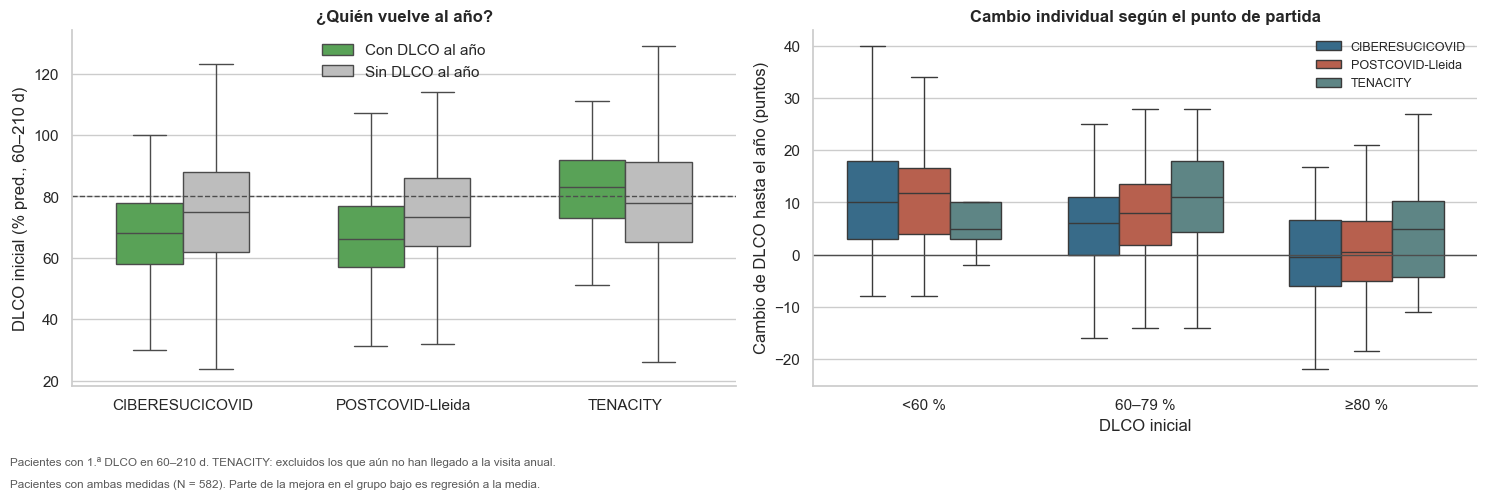

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
ax = axes[0]
dd = par_ev[par_ev["registro"].isin([r for r in REG if ETQ[r] in tabla_abandono.index])].copy()
dd["seguimiento"] = np.where(dd["con_anual"], "Con DLCO al año", "Sin DLCO al año")
sns.boxplot(data=dd, x="registro", y="dlco_ini", hue="seguimiento", ax=ax, showfliers=False,
            palette=["#4daf4a", "#bdbdbd"], hue_order=["Con DLCO al año", "Sin DLCO al año"], order=[r for r in REG if r in dd["registro"].unique()], width=0.6)
ax.set_xticklabels([ETQ[t.get_text()] for t in ax.get_xticklabels()])
ax.axhline(UMB["dlco_pct"], color="0.3", ls="--", lw=1)
ax.set_xlabel(""); ax.set_ylabel(f"DLCO inicial (% pred., {v0}–{v1} d)"); ax.set_title("¿Quién vuelve al año?")
ax.legend(frameon=False, title="")

ax = axes[1]
pp = par_ev[par_ev["con_anual"]].copy()
pp["cambio"] = pp["dlco_anual"] - pp["dlco_ini"]
pp["DLCO inicial"] = pd.cut(pp["dlco_ini"], [0, 60, 80, 200], labels=["<60 %", "60–79 %", "≥80 %"])
sns.boxplot(data=pp, x="DLCO inicial", y="cambio", hue="registro", ax=ax, showfliers=False,
            palette=COLOR, hue_order=[r for r in REG if r in pp["registro"].unique()], width=0.7)
ax.axhline(0, color="0.3", lw=1)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [ETQ[l] for l in labels], frameon=False, fontsize=9)
ax.set_ylabel("Cambio de DLCO hasta el año (puntos)"); ax.set_title("Cambio individual según el punto de partida")
nota(axes[0], f"Pacientes con 1.ª DLCO en {v0}–{v1} d. TENACITY: excluidos los que aún no han llegado a la visita anual.")
nota(ax, f"Pacientes con ambas medidas (N = {len(pp):,}). Parte de la mejora en el grupo bajo es regresión a la media.")
plt.tight_layout(); guardar(fig, "08_abandono_informativo"); plt.show()

**Lectura: abandono informativo.**
- **Los que no vuelven partían mejor.** En CIBERESUCICOVID y en Lleida, quienes no tienen DLCO al año empezaron unos 6–7 puntos por encima (p < 10⁻⁵): dejan de acudir porque están mejor, o porque no se les repite la prueba. La curva poblacional del apartado anterior **infravalora** la DLCO al año.
- **Corrección necesaria:** las trayectorias necesitan pesos IPW o un análisis por patrón de abandono, como prevé el plan. En TENACITY no se ve la diferencia, pero el N es pequeño.
- La mejora individual es mayor cuanto peor es el punto de partida. Parte de ese efecto es regresión a la media, así que un modelo mixto con intercepto y pendiente aleatorios es preferible a comparar cambios brutos.
- En TENACITY hay que distinguir el abandono de los pacientes a los que todavía no les toca la visita anual, porque el reclutamiento sigue abierto.

## 9 · Dominios de la capa B: ansiedad, depresión y disnea en el tiempo

Solo Lleida y TENACITY recogen HADS. Se usan las puntuaciones totales de cada visita (`*_had_a_puntuacion`, `*_had_d_puntuacion`) y la disnea mMRC (`*_disnea_mmrc`).

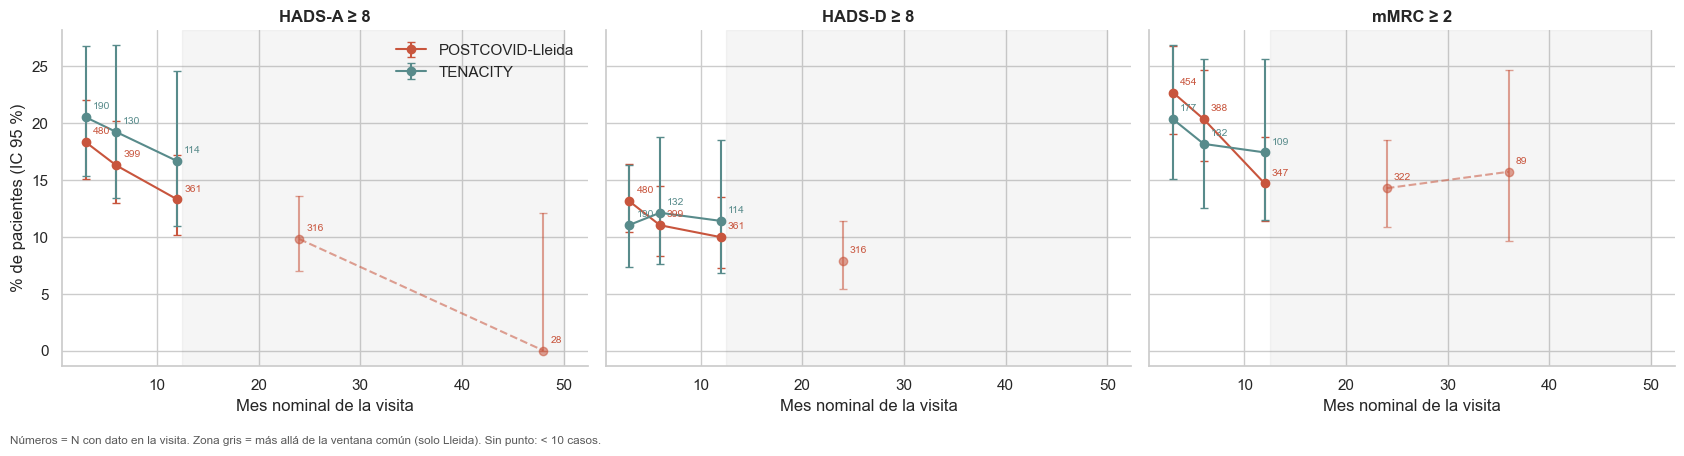

In [30]:
visitas_b = {"POSTCOVID_LLEIDA": [("LV1", 3), ("LV2", 6), ("LA1", 12), ("LM18", 18), ("LM24", 24), ("LA3", 36), ("LA4", 48)],
             "TENACITY": [("M3", 3), ("M6", 6), ("A1", 12)]}
cols_b = [f"{p}_{v}" for vs in visitas_b.values() for p, _ in vs for v in ("had_a_puntuacion", "had_d_puntuacion", "disnea_mmrc")]
cb = carga.cargar_columnas_completa(cfg, cols_b).merge(nucleo[["subject_id", *cfg["registros"].values()]], on="subject_id")

filas = []
for r, vs in visitas_b.items():
    sub = cb[cb[cfg["registros"][r]] == 1]
    for p, mes in vs:
        for v, nombre, u in [("had_a_puntuacion", "HADS-A ≥ 8", UMB["hads"]), ("had_d_puntuacion", "HADS-D ≥ 8", UMB["hads"]),
                             ("disnea_mmrc", "mMRC ≥ 2", UMB["mmrc"])]:
            s = sub[f"{p}_{v}"].dropna()
            k = int((s >= u).sum())
            if len(s) >= N_MIN and (k == 0 or k >= N_MIN):
                lo, hi = ic_wilson(k, len(s))
                filas.append({"registro": r, "visita": p, "mes": mes, "medida": nombre, "n": len(s),
                              "pct": 100 * k / len(s), "lo": lo, "hi": hi, "mediana": s.median()})
capa_b = pd.DataFrame(filas)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4), sharey=True)
for ax, medida in zip(axes, ["HADS-A ≥ 8", "HADS-D ≥ 8", "mMRC ≥ 2"]):
    for r in visitas_b:
        s = capa_b[(capa_b["registro"] == r) & (capa_b["medida"] == medida)]
        com = s[s["mes"] <= 12]; ext = s[s["mes"] > 12]
        ax.errorbar(com["mes"], com["pct"], yerr=[com["pct"] - com["lo"], com["hi"] - com["pct"]], fmt="o-",
                    color=COLOR[r], capsize=3, label=ETQ[r])
        if len(ext):
            ax.errorbar(ext["mes"], ext["pct"], yerr=[ext["pct"] - ext["lo"], ext["hi"] - ext["pct"]], fmt="o--",
                        color=COLOR[r], capsize=3, alpha=0.55)
        for x, y, n in zip(s["mes"], s["pct"], s["n"]):
            ax.annotate(f"{n}", (x, y), textcoords="offset points", xytext=(5, 6), fontsize=7.5, color=COLOR[r])
    ax.axvspan(12.5, 50, color="0.5", alpha=0.08)
    ax.set_title(medida); ax.set_xlabel("Mes nominal de la visita")
axes[0].set_ylabel("% de pacientes (IC 95 %)"); axes[0].legend(frameon=False)
nota(axes[0], f"Números = N con dato en la visita. Zona gris = más allá de la ventana común (solo Lleida). Sin punto: < {N_MIN} casos.")
plt.tight_layout(); guardar(fig, "09_capa_b_hads_mmrc"); plt.show()

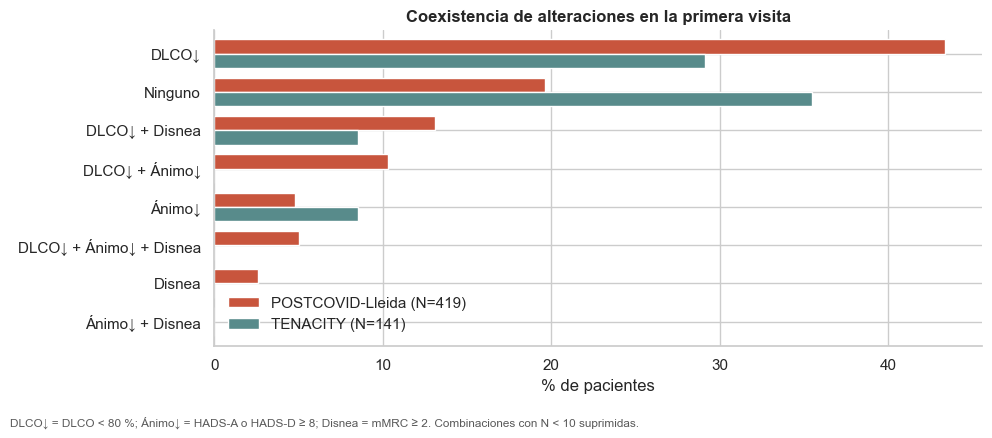

In [31]:
# Coexistencia de dominios en la primera visita (Lleida LV1, TENACITY M3)
fun_b = carga.cargar_columnas_completa(cfg, ["LV1_dlco_porcentage", "M3_dlco"])
cb2 = cb.merge(fun_b, on="subject_id")
filas = []
for r, p, col_dlco in [("POSTCOVID_LLEIDA", "LV1", "LV1_dlco_porcentage"), ("TENACITY", "M3", "M3_dlco")]:
    s = cb2[cb2[cfg["registros"][r]] == 1].dropna(subset=[col_dlco, f"{p}_had_a_puntuacion", f"{p}_had_d_puntuacion", f"{p}_disnea_mmrc"])
    pulmon = s[col_dlco] < UMB["dlco_pct"]
    animo = (s[f"{p}_had_a_puntuacion"] >= UMB["hads"]) | (s[f"{p}_had_d_puntuacion"] >= UMB["hads"])
    disnea = s[f"{p}_disnea_mmrc"] >= UMB["mmrc"]
    combo = (pulmon.map({True: "DLCO↓", False: ""}) + " " + animo.map({True: "Ánimo↓", False: ""}) + " " +
             disnea.map({True: "Disnea", False: ""})).str.split().str.join(" + ").replace("", "Ninguno")
    vc = combo.value_counts()
    for k, n in vc.items():
        filas.append({"registro": ETQ[r], "combinación": k, "n": n, "pct": 100 * n / len(s), "N": len(s)})
coex = pd.DataFrame(filas)
coex_tab = coex.pivot_table(index="combinación", columns="registro", values="pct").round(1)
coex_n = coex.pivot_table(index="combinación", columns="registro", values="n")
coex_tab = coex_tab.where(coex_n >= N_MIN).fillna(np.nan)
orden = coex.groupby("combinación")["pct"].mean().sort_values(ascending=False).index
coex_tab = coex_tab.loc[orden]

fig, ax = plt.subplots(figsize=(10, 4.2))
coex_tab.plot.barh(ax=ax, color=[COLOR["POSTCOVID_LLEIDA"], COLOR["TENACITY"]], width=0.75)
ax.invert_yaxis(); ax.set_xlabel("% de pacientes"); ax.set_ylabel("")
ax.set_title("Coexistencia de alteraciones en la primera visita")
ax.legend([f"{c} (N={int(coex[coex['registro']==c]['N'].iloc[0])})" for c in coex_tab.columns], frameon=False)
nota(ax, f"DLCO↓ = DLCO < {UMB['dlco_pct']} %; Ánimo↓ = HADS-A o HADS-D ≥ {UMB['hads']}; Disnea = mMRC ≥ {UMB['mmrc']}. "
         f"Combinaciones con N < {N_MIN} suprimidas.")
plt.tight_layout(); guardar(fig, "09_coexistencia_dominios"); plt.show()

**Lectura.**
- **Las prevalencias se parecen en Lleida y TENACITY durante el primer año**, con intervalos solapados: ansiedad posible (HADS-A ≥ 8) en el 18–20 % a los 3 meses, depresión posible (HADS-D ≥ 8) en el 11–13 % y disnea mMRC ≥ 2 en el 20–23 %. Es buena señal para replicar la capa B.
- **Ansiedad y disnea bajan despacio** (en Lleida, la ansiedad pasa del 18 % al 10 % a los 2 años). La depresión se mantiene estable durante el primer año. Su evolución no sigue a la de la DLCO.
- **La combinación más frecuente es la DLCO baja aislada.** Le siguen "ninguna alteración" y la DLCO baja con disnea o con ánimo bajo. TENACITY tiene más pacientes sin ninguna alteración. Esa mezcla parcial de dominios es la que el clustering multidominio tiene que capturar y replicar entre Lleida y TENACITY.

## 10 · Imagen torácica (TAC)

- **Lleida y TENACITY**: solo formularios con `*_tacimagen_complete == 2`. Las casillas `___N` valen 0 aunque nadie haya rellenado el formulario. Fibrosis **estricta** = lesiones fibróticas (código 1). **Amplia** = fibróticas o reticulares (1 o 2). Con el formulario completo, la variable vacía se interpreta como "sin lesión" (supuesto a validar con el equipo clínico).
- **CIBERESUCICOVID**: "tractos fibrosos" en pacientes con TAC hecho. **No es el mismo constructo**, así que se compara solo dentro de la cohorte.

In [32]:
cols_img = ["M3_tac_followup", "M3_result_tac_followup___3", "M6_tac_followup", "M6_result_tac_followup___3",
            "A1_tac_followup_2", "A1_result_tac_followup_2___3"]
vis_img = {"POSTCOVID_LLEIDA": [("LV1", 3), ("LV2", 6), ("LA1", 12), ("LM24", 24), ("LA3", 36)],
           "TENACITY": [("M3", 3), ("M6", 6)]}
cols_img += [f"{p}_{v}" for vs in vis_img.values() for p, _ in vs for v in ("tacimagen_complete", "fibetic_reticular_lesions")]
im = carga.cargar_columnas_completa(cfg, cols_img).merge(nucleo[["subject_id", *cfg["registros"].values(), "fusionada_lleida"]], on="subject_id")

filas = []
cib_im = im[im["en_CIBERESUCICOVID"] == 1]
for p, mes, hecho, fib in [("M3", 3, "M3_tac_followup", "M3_result_tac_followup___3"),
                           ("M6", 6, "M6_tac_followup", "M6_result_tac_followup___3"),
                           ("A1", 12, "A1_tac_followup_2", "A1_result_tac_followup_2___3")]:
    con_visita = cib_im[hecho].notna().sum(); con_tac = cib_im[hecho] == 1
    s = cib_im.loc[con_tac, fib]
    filas.append({"registro": "CIBERESUCICOVID", "visita": p, "mes": mes, "definición": "Tractos fibrosos",
                  "con formulario/visita": int(con_visita), "con TAC válido": int(con_tac.sum()),
                  "% TAC sobre visitas": 100 * con_tac.sum() / con_visita, "% hallazgo": 100 * s.mean()})
for r, vs in vis_img.items():
    sub = im[im[cfg["registros"][r]] == 1]
    for p, mes in vs:
        comp = sub[f"{p}_tacimagen_complete"] == 2
        f = sub.loc[comp, f"{p}_fibetic_reticular_lesions"]
        for nombre, val in [("Fibrosis estricta", f == 1), ("Fibrosis amplia", f.isin([1, 2]))]:
            k = int(val.sum())
            filas.append({"registro": r, "visita": p, "mes": mes, "definición": nombre,
                          "con formulario/visita": int(sub[f"{p}_tacimagen_complete"].notna().sum()),
                          "con TAC válido": int(comp.sum()),
                          "% TAC sobre visitas": 100 * comp.sum() / max(sub[f"{p}_tacimagen_complete"].notna().sum(), 1),
                          "% hallazgo": 100 * val.mean() if comp.sum() >= N_MIN and k >= N_MIN else np.nan})
tac = pd.DataFrame(filas)
tac_vista = tac.assign(registro=tac["registro"].map(ETQ)).set_index(["registro", "visita", "definición"]).round(1)
privacidad.suprimir_celdas(tac_vista, N_MIN, ["con TAC válido"])

mes  con formulario/visita  con TAC válido  % TAC sobre visitas  % hallazgo
registro         visita definición                                                                                    
CIBERESUCICOVID  M3     Tractos fibrosos     3                   3663            1107                 30.2        22.0
                 M6     Tractos fibrosos     6                   3323            1017                 30.6        27.3
                 A1     Tractos fibrosos    12                   3282             652                 19.9        28.8
POSTCOVID-Lleida LV1    Fibrosis estricta    3                    624             266                 42.6        23.3
                        Fibrosis amplia      3                    624             266                 42.6        67.3
                 LV2    Fibrosis estricta    6                    456             172                 37.7        28.5
                        Fibrosis amplia      6                    456             172                 37.7        72.1
                 LA1    Fibrosis estricta   12                    521             112                 21.5        30.4
                        Fibrosis amplia     12                    521             112                 21.5        82.1
                 LM24   Fibrosis estricta   24                    364             145                 39.8        18.6
                        Fibrosis amplia     24                    364             145                 39.8        60.0
                 LA3    Fibrosis estricta   36                     93              38                 40.9        39.5
                        Fibrosis amplia     36                     93              38                 40.9        89.5
TENACITY         M3     Fibrosis estricta    3                    286              34                 11.9         NaN
                        Fibrosis amplia      3                    286              34                 11.9        52.9
                 M6     Fibrosis estricta    6                    169              29                 17.2         NaN
                        Fibrosis amplia      6                    169              29                 17.2         NaN

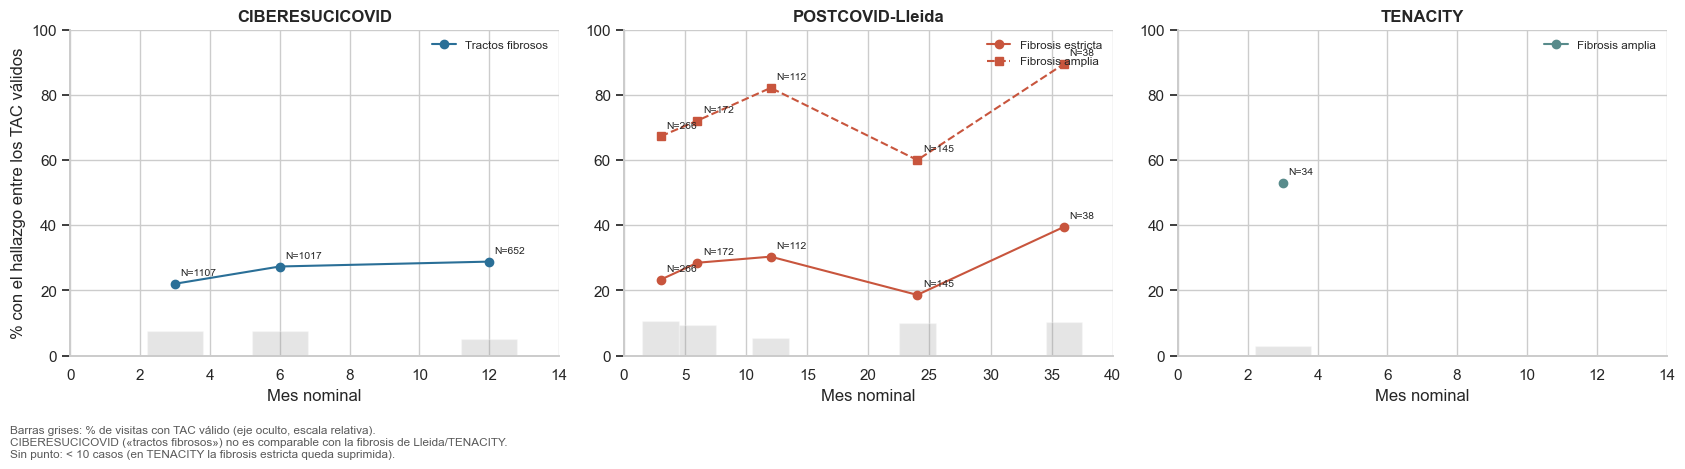

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for ax, r in zip(axes, ["CIBERESUCICOVID", "POSTCOVID_LLEIDA", "TENACITY"]):
    s = tac[(tac["registro"] == r) & tac["% hallazgo"].notna()]
    for (defin, d), estilo in zip(s.groupby("definición", sort=False), ["o-", "s--"]):
        ax.plot(d["mes"], d["% hallazgo"], estilo, color=COLOR[r], label=defin, ms=6)
        for x, y, n in zip(d["mes"], d["% hallazgo"], d["con TAC válido"]):
            ax.annotate(f"N={n}", (x, y), textcoords="offset points", xytext=(4, 6), fontsize=7.5)
    ax2 = ax.twinx()
    dd = s.drop_duplicates("visita")
    ax2.bar(dd["mes"], dd["% TAC sobre visitas"], width=1.6 if r != "POSTCOVID_LLEIDA" else 3, color="0.6", alpha=0.25)
    ax2.set_ylim(0, 400); ax2.set_yticks([]); ax2.grid(False)
    ax.set_xlim(0, 40 if r == "POSTCOVID_LLEIDA" else 14)
    ax.set_title(ETQ[r]); ax.set_xlabel("Mes nominal"); ax.set_ylim(0, 100);ax.legend(frameon=False, fontsize=8.5, loc="upper right")
axes[0].set_ylabel("% con el hallazgo entre los TAC válidos")
nota(axes[0], "Barras grises: % de visitas con TAC válido (eje oculto, escala relativa).\n"
              "CIBERESUCICOVID («tractos fibrosos») no es comparable con la fibrosis de Lleida/TENACITY.\n"
              f"Sin punto: < {N_MIN} casos (en TENACITY la fibrosis estricta queda suprimida).")
plt.tight_layout(); guardar(fig, "10_tac_fibrosis"); plt.show()

**Lectura.**
- **Los TAC se repiten de forma selectiva.** En CIBERESUCICOVID, la proporción de visitas con TAC baja del 30 % al 20 % al año, mientras que los "tractos fibrosos" suben del 22 % al 29 %: se repite el TAC a quien tenía lesiones. En Lleida el porcentaje con fibrosis no baja con el tiempo por el mismo motivo. **Estos porcentajes no son prevalencias de cohorte.**
- **La definición de fibrosis decide la cifra.** En Lleida, la definición amplia (fibrótica o reticular) da un 60–90 % frente al 19–40 % de la estricta. Es una decisión clínica con mucho impacto, así que se presentarán las dos.
- **TENACITY casi no tiene TAC utilizables:** solo 34 formularios completos en M3 y 29 en M6, y la fibrosis estricta tiene menos de 10 casos. La imagen no puede definir fenotipos que se repliquen en TENACITY: queda como variable de **descripción**.

## 11 · Resumen de hallazgos e implicaciones para el fenotipado

In [34]:
n_cib_dlco = int(nucleo.loc[nucleo["en_CIBERESUCICOVID"] == 1, "nu_dlco_pct_seg"].notna().sum())
n_cib_dlco_nofus = int(nucleo.loc[(nucleo["en_CIBERESUCICOVID"] == 1) & (nucleo["fusionada_lleida"] == 0), "nu_dlco_pct_seg"].notna().sum())
claves = pd.DataFrame([
    ("Pacientes únicos", f"{len(nucleo):,}"),
    ("CIBERESUCICOVID con DLCO en 1.ª visita (todos / sin fusionados Lleida)", f"{n_cib_dlco:,} / {n_cib_dlco_nofus:,}"),
    ("Pacientes de Lleida en filas de CIBERESUCICOVID", f"{int(nucleo['fusionada_lleida'].sum())} de {int(nucleo['en_POSTCOVID_LLEIDA'].sum())}"),
    ("Medidas de DLCO válidas, sin duplicados (pacientes)", f"{len(dlco_u):,} ({dlco_u['subject_id'].nunique():,})"),
    ("Pacientes con ≥2 DLCO", f"{(dlco_u.groupby('subject_id').size() >= 2).sum():,}"),
    ("visita_dias negativos (excluir)", f"{int((nucleo['visita_dias'] < 0).sum())}"),
    ("CIBERESUCICOVID con IH_PorcCMD < 50", f"{int((nucleo['IH_PorcCMD'] < u_p).sum()):,}"),
], columns=["indicador", "valor"]).set_index("indicador")
claves.to_csv(TAB / "11_indicadores_clave.csv")
claves

,valor
indicador,
Pacientes únicos,"9,809"
CIBERESUCICOVID con DLCO en 1.ª visita (todos / sin fusionados Lleida),"1,289 / 871"
Pacientes de Lleida en filas de CIBERESUCICOVID,437 de 624
"Medidas de DLCO válidas, sin duplicados (pacientes)","4,176 (2,353)"
Pacientes con ≥2 DLCO,"1,071"
visita_dias negativos (excluir),54
CIBERESUCICOVID con IH_PorcCMD < 50,"2,730"


### Hallazgos

1. **El N efectivo es mucho menor que el N total.** De 9.809 pacientes, solo 2.353 tienen alguna DLCO válida. En CIBERESUCICOVID, la capa A se descubre en 1.289 pacientes (871 sin los fusionados con Lleida), no en 9.274, y quién tiene DLCO depende sobre todo del **centro**.
2. **Las cohortes miden en momentos distintos, y además son distintas.** Virgen del Rocío mide al mes y el resto a los 3–4 meses, y la DLCO sube en los primeros meses, así que hay que usar `visita_dias` con una ventana común de 60–210 días. Incluso en la misma ventana, TENACITY está unos 10 puntos por encima: por eso umbrales clínicos y no z-scores.
3. **La DLCO baja domina.** Aislada o junto con FVC baja, afecta a dos de cada tres pacientes, y la FVC baja aislada es rara salvo en TENACITY. Es el eje natural de la capa A.
4. **Pulmón, esfuerzo, disnea y ánimo están poco correlacionados** (|ρ| ≤ 0,23), y la ansiedad y la depresión evolucionan a su propio ritmo. Esto justifica la capa B multidominio. Sus prevalencias son parecidas en Lleida y TENACITY, lo que favorece la replicación.
5. **El abandono es informativo.** En CIBERESUCICOVID y en Lleida, los que no vuelven al año partían unos 6–7 puntos de DLCO por encima, así que las curvas brutas infravaloran la recuperación. Para corregirlo se necesitan IPW o curvas por patrón de abandono.
6. **Hay datos duplicados entre registros.** La DLCO de los 437 fusionados Lleida–CIBERESUCICOVID es la misma prueba. Deben contar una sola vez en las trayectorias y estar en un solo lado de la replicación.
7. **La imagen se repite de forma selectiva** y es casi inexistente en TENACITY. Los TAC tardíos se hacen a quien tenía lesiones, y la definición de fibrosis (estricta o amplia) cambia la cifra en un factor de 2–3.

### Decisiones propuestas para `config.yaml` y `docs/registro_decisiones.md` (las valida el equipo)

| Decisión | Propuesta | Motivo (sección) |
|---|---|---|
| Ventana de definición | 60–210 días tras el alta | Momento común de Lleida, TENACITY y CIBERESUCICOVID (§6, §7) |
| Variables de definición, capa A | DLCO < 80, FVC < 80 (no FEV1, redundante) | Cobertura en los 4 registros; correlación FVC–FEV1 (§3, §7) |
| Variables de definición, capa B | + HADS-A/D ≥ 8, mMRC ≥ 2, PM6M | Solo Lleida y TENACITY (§3, §9) |
| Variables de descripción | Edad, sexo, comorbilidad, estancia, UCI, traqueotomía, TAC | Fase aguda; imagen selectiva y escasa en TENACITY (§5, §10) |
| `visita_dias < 0` | Excluir | Error de fecha (§2.3) |
| Fusionados Lleida | Quitar del lado CIBERESUCICOVID al replicar | Prueba duplicada (§1, §8) |
| `IH_PorcCMD` | ≥ 50 principal, ≥ 99 sensibilidad | Cambia la población, no solo la calidad (§2.1) |
| Código 9 | → ausente | Sobre todo tabaquismo (§2.2) |
| Validación de la capa A | Leave-one-center-out en CIBERESUCICOVID | Heterogeneidad por centro en la medición (§3.1) |
| Trayectorias | Modelo mixto + IPW; extensión > 12 m solo con Lleida | Abandono informativo (§8) |

> **Nota (equipo clínico):** <!-- TODO equipo: validar umbrales, definición de fibrosis y la interpretación de que un TAC completo sin lesión marcada = sin lesión. -->